<a href="https://colab.research.google.com/github/lynnfdsouza/Counterterrorism/blob/main/gti_kk2233.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Summary:

### Data Analysis Key Findings

*   **Time Period Analyzed**: The analysis covered the period from 2011 to 2024, utilizing 14 years of data.
*   **Global Trends**: The global terrorism metric showed a total increase of 52.2 points over the analyzed period, ranging from a minimum of 280.6 to a maximum of 332.8.
*   **Identified Change Points**: Two significant change points were detected: a notable increase in 2015 (+\$33.1\$, 11.4%) and a decrease in 2020 (-\$26.3\$, -8.0%).
*   **Regional Insights**: Regional data for 163 distinct regions/countries was identified and analyzed, with cycle fitting performed for each.
*   **Performance of Fitted Cycles**:
    *   The Kondratiev Wave (50-year cycle) fit the global data with an RMSE of 12.83 and an R² of 0.565.
    *   The Kuznets Cycle (20-year cycle) provided a better fit with an RMSE of 11.83 and an R² of 0.630.
    *   The Kuznets cycle was identified as the best-fitting model for the global terrorism data due to its lower Root Mean Squared Error (RMSE) and higher R² value.

### Insights or Next Steps

*   **Focus on Kuznets Cycle for Forecasting**: Given that the Kuznets cycle (20-year period) demonstrated a better fit (lower RMSE, higher R²) to the historical global terrorism data compared to the Kondratiev wave, it should be prioritized for future short-to-medium term forecasting and policy considerations.
*   **Integrate Real Economic Indicators**: To enhance the predictive power and causal understanding of terrorism cycles, future analysis should replace simulated economic indicators with real historical data from sources like the World Bank or FRED to identify genuine correlations.


In [3]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Historical data: Approximate UCDP state-based conflicts
years = np.array([1946, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2022, 2023, 2024])
conflicts = np.array([5, 8, 15, 25, 40, 50, 35, 40, 56, 56, 59, 61])

# Sine function for cycle fitting
def sine_func(x, A, phase, mean, period=50):  # Default: Kondratiev
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

# Fit Kondratiev (P=50)
popt_k = curve_fit(sine_func, years, conflicts, p0=[10, 1900, 30, 50])[0]
print('Kondratiev Fit: A=%.2f, Phase=%.0f, Mean=%.1f' % (popt_k[0], popt_k[1], popt_k[2]))

# Fit Kuznets (P=20)
popt_z = curve_fit(lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20), years, conflicts, p0=[10, 1900, 30])[0]
print('Kuznets Fit: A=%.2f, Phase=%.0f, Mean=%.1f' % (popt_z[0], popt_z[1], popt_z[2]))

# Predictions: 2020-2030
future_years = np.arange(2020, 2031)
k_preds = sine_func(future_years, *popt_k)
z_preds = sine_func(future_years, *popt_z, 20)

print('\nYear | Kondratiev Pred | Kuznets Pred | Actual (2020-24)')
for i, y in enumerate(future_years[:5]):
    actual = conflicts[-5 + i] if i < 5 else 'N/A'
    print(f'{y} | {k_preds[i]:.1f} | {z_preds[i]:.1f} | {actual}')

# Plot (uncomment to visualize)
# plt.plot(years, conflicts, 'o', label='Data')
# plt.plot(future_years, k_preds, '--', label='Kondratiev Fit')
# plt.plot(future_years, z_preds, '-.', label='Kuznets Fit')
# plt.xlabel('Year'); plt.ylabel('Conflicts'); plt.legend(); plt.show()

Kondratiev Fit: A=18.34, Phase=1918, Mean=35.0
Kuznets Fit: A=10.84, Phase=1898, Mean=34.4

Year | Kondratiev Pred | Kuznets Pred | Actual (2020-24)
2020 | 50.0 | 41.4 | 40
2021 | 51.2 | 43.6 | 56
2022 | 52.2 | 44.9 | 56
2023 | 52.9 | 45.2 | 59
2024 | 53.2 | 44.4 | 61


In [10]:
print(df_overall_scores.iloc[:10].to_string()) # Display first 10 rows of 'Overall Scores' sheet

                                                                                                                                                                                                                                                                                                                                                                  Unnamed: 0                                            Unnamed: 1  Unnamed: 2 Unnamed: 3  Unnamed: 4 Unnamed: 5  Unnamed: 6 Unnamed: 7  Unnamed: 8 Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15 Unnamed: 16 Unnamed: 17 Unnamed: 18 Unnamed: 19 Unnamed: 20 Unnamed: 21 Unnamed: 22 Unnamed: 23 Unnamed: 24 Unnamed: 25 Unnamed: 26 Unnamed: 27 Unnamed: 28 Unnamed: 29
0                                                                                                                                                                                                                                                        

In [11]:
import pandas as pd

df_overall_scores = pd.read_excel('/content/GTI_PublicReleaseData_2025.xlsx', sheet_name='Overall Scores', header=5)
pd.set_option('display.max_columns', None) # Display all columns
display(df_overall_scores.head())

,The content of this spreadsheet is the copyright of The Institute for Economics and Peace Limited (IEP). IEP grants each recipient authorised by IEP a licence to use this data only for its own internal non-commercial purposes. The licence includes no right to sub-licence and the data may not be distributed in excel format to any person without IEP’s consent.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,country,iso3c,2011 score,2011 rank,2012 score,2012 rank,2013 score,2013 rank,2014 score,2014 rank,2015 score,2015 rank,2016 score,2016 rank,2017 score,2017 rank,2018 score,2018 rank,2019 score,2019 rank,2020 score,2020 rank,2021 score,2021 rank,2022 score,2022 rank,2023 score,2023 rank,2024 score,2024 rank
1,Afghanistan,AFG,8.784,3,8.825,3,8.59,3,8.547,4,8.505,3,8.33,3,8.494,2,8.746,2,8.715,1,8.734,1,8.818,1,8.459,1,7.834,6,7.262,9
2,Angola,AGO,1.741,66,1.207,74,0.632,82,0.915,74,0.423,91,0.233,95,0.114,104,0.462,90,0.233,96,0.123,91,0.059,89,0.03,91,2.254,45,1.657,51
3,Albania,ALB,0.423,92,0.229,101,0.114,101,0.044,105,0,107,0,106,0,107,0,109,0,111,0,104,0,96,0,94,0,94,0,100
4,United Arab Emirates,ARE,0,114,0,113,0,111,1.293,70,1.136,75,0.72,79,0.406,92,0.217,99,0.044,108,0,104,0,96,0.423,77,0.233,85,1.178,67


In [8]:
import pandas as pd

xcel_file = pd.ExcelFile('/content/GTI_PublicReleaseData_2025.xlsx')
sheet_names = xcel_file.sheet_names
print("Sheet names in the Excel file:")
for sheet in sheet_names:
    print(f"- {sheet}")

Sheet names in the Excel file:
- Contents
- Overall Scores
- 2024
- 2023
- 2022
- 2021
- 2020
- 2019
- 2018
- 2017
- 2016
- 2015
- 2014
- 2013
- 2012
- 2011


In [14]:
!pip install pandas numpy scipy matplotlib openpyxl
!python gti_analysis.py

python3: can't open file '/content/gti_analysis.py': [Errno 2] No such file or directory


# Task
The previous code failed to correctly extract the time series data for analysis because the DataFrame `df_full` did not have the expected column names like '2011 score', '2012 score', etc. This was due to an incorrect manual header extraction in the previous step.

Fortunately, the `df_overall_scores` DataFrame, which was loaded successfully in an earlier step (cell `885de5a2`) using `header=5`, already contains the correct column names for the 'Overall Scores' sheet.

To rectify this, I will modify the current code to directly use `df_overall_scores` as the main dataset for time series extraction, instead of re-loading and manually parsing the header. This will ensure that the `extract_time_series` function can correctly identify the score columns and proceed with the analysis as planned.

I will modify the cell `2keQ5h8-016b` by replacing the faulty header extraction logic with a direct assignment of `df_overall_scores` to `df_full`.

```python
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# Load main dataset - CORRECTED FOR ROBUST HEADER EXTRACTION
# Use the already correctly loaded df_overall_scores from a previous cell.
# This avoids re-parsing the header incorrectly.
if 'df_overall_scores' in locals():
    df_full = df_overall_scores.copy()
else:
    # Fallback: if df_overall_scores is not in locals (e.g., if this cell is run standalone)
    # This part should ideally not be reached if the notebook is run sequentially.
    df_full = pd.read_excel(file_path, sheet_name='Overall Scores', header=5)


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        values = df_clean[score_cols].sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "↑" if cp['change'] > 0 else "↓"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R²: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R²: {r2_z:.3f}")
        print()
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R²: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R²: {r2_z_region:.3f}")
            print()
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(future_years, k_forecast, '--', label='Kondratiev Forecast', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(future_years, z_forecast, '--', label='Kuznets Forecast', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            if 'r2_k' in locals() and 'r2_z' in locals():
                if r2_k < r2_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)
```

## List Excel Sheet Names

### Subtask:
List all sheet names in the Excel file to confirm the naming convention for the year-specific sheets.


**Reasoning**:
The subtask explicitly asks to list all sheet names. Although a similar action was performed before, I will generate a new code block as instructed to fulfill the current subtask requirement precisely.



In [3]:
import pandas as pd

xcel_file = pd.ExcelFile('/content/GTI_PublicReleaseData_2025.xlsx')
sheet_names = xcel_file.sheet_names
print("Sheet names in the Excel file:")
for sheet in sheet_names:
    print(f"- {sheet}")

Sheet names in the Excel file:
- Contents
- Overall Scores
- 2024
- 2023
- 2022
- 2021
- 2020
- 2019
- 2018
- 2017
- 2016
- 2015
- 2014
- 2013
- 2012
- 2011


## Inspect a Sample Year Sheet

### Subtask:
Load and inspect the first few rows of one of the year-specific sheets (e.g., '2024') without a header to understand its structure and identify where the actual column headers and data begin.


**Reasoning**:
To understand the structure of a year-specific sheet, I need to load it without a header and inspect its initial rows and column names. This will help identify the actual header row and data start.



In [4]:
df_2024_raw = pd.read_excel('/content/GTI_PublicReleaseData_2025.xlsx', sheet_name='2024', header=None)
display(df_2024_raw.head(10))
print(df_2024_raw.columns.tolist())

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,© The Institute for Economics and Peace Limite...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,The content of this spreadsheet is the copyrig...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Country,iso3c,rank,Score,Incidents,Fatalities,Hostages,Injuries
7,NaN,Burkina Faso,BFA,1,8.581,111,1532,8,206
8,NaN,Pakistan,PAK,2,8.374,1099,1081,101,1548
9,NaN,Syria,SYR,3,8.006,430,744,53,408


[0, 1, 2, 3, 4, 5, 6, 7, 8]


## Extract and Consolidate Data from Year Sheets

### Subtask:
Extract relevant data from each year-specific sheet and combine it into a single DataFrame.


**Reasoning**:
To extract and consolidate data from year-specific sheets, I will first initialize an empty list to store the processed DataFrames. Then, I will iterate through each sheet name, check if it represents a year, load the data with the correct header, select the specified columns, add a 'Year' column, and finally concatenate all individual DataFrames into a single comprehensive DataFrame.



In [5]:
all_years_data = []

# Iterate through all sheet names
for sheet in sheet_names:
    try:
        # Check if the sheet name is a year (e.g., '2011', '2024')
        year = int(sheet)
        if 2011 <= year <= 2024: # Assuming years from 2011 to 2024 based on sheet_names
            # Load the sheet with header=6 (actual data starts after 6 rows)
            df_year = pd.read_excel(file_path, sheet_name=sheet, header=6)

            # Select required columns, ensuring they exist and handling potential case differences
            required_cols = ['Country', 'Score', 'Incidents', 'Fatalities', 'Hostages', 'Injuries']
            # Filter columns that are actually present in the DataFrame
            available_cols = [col for col in required_cols if col in df_year.columns]

            if len(available_cols) == len(required_cols): # Ensure all critical columns are present
                df_year_processed = df_year[available_cols].copy()
                df_year_processed['Year'] = year
                all_years_data.append(df_year_processed)
            else:
                print(f"Warning: Skipping sheet '{sheet}' due to missing columns. Expected: {required_cols}, Found: {df_year.columns.tolist()}")

    except ValueError:
        # Sheet name is not a year, skip it
        continue

# Concatenate all DataFrames into a single one
if all_years_data:
    gti_yearly_data = pd.concat(all_years_data, ignore_index=True)
    print("Consolidated GTI yearly data created.")
    print(f"Shape: {gti_yearly_data.shape}")
    print(f"Columns: {gti_yearly_data.columns.tolist()}")
    display(gti_yearly_data.head())
else:
    print("No yearly data found or processed.")
    gti_yearly_data = pd.DataFrame() # Initialize empty DataFrame


Consolidated GTI yearly data created.
Shape: (2282, 7)
Columns: ['Country', 'Score', 'Incidents', 'Fatalities', 'Hostages', 'Injuries', 'Year']


,Country,Score,Incidents,Fatalities,Hostages,Injuries,Year
0,Burkina Faso,8.581,111,1532,8,206,2024
1,Pakistan,8.374,1099,1081,101,1548,2024
2,Syria,8.006,430,744,53,408,2024
3,Mali,7.907,201,604,292,158,2024
4,Niger,7.776,101,930,35,158,2024


## Prepare Consolidated Data for Analysis

### Subtask:
Process the `gti_yearly_data` DataFrame to create `years` and `global_values` arrays, aggregating the data appropriately (e.g., sum of scores) to represent the global terrorism metric over time. This step will also extract regional data if available.


## Perform Cycle Analysis and Forecasting

### Subtask:
Perform Kondratiev and Kuznets cycle fitting, calculate performance metrics, and generate 10-year forecasts using the prepared time series data.


**Reasoning**:
The subtask requires executing the code in cell `2keQ5h8-016b` which performs cycle fitting, calculates performance metrics, and generates forecasts using the prepared time series data. This execution will verify the updated logic for data loading and analysis.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

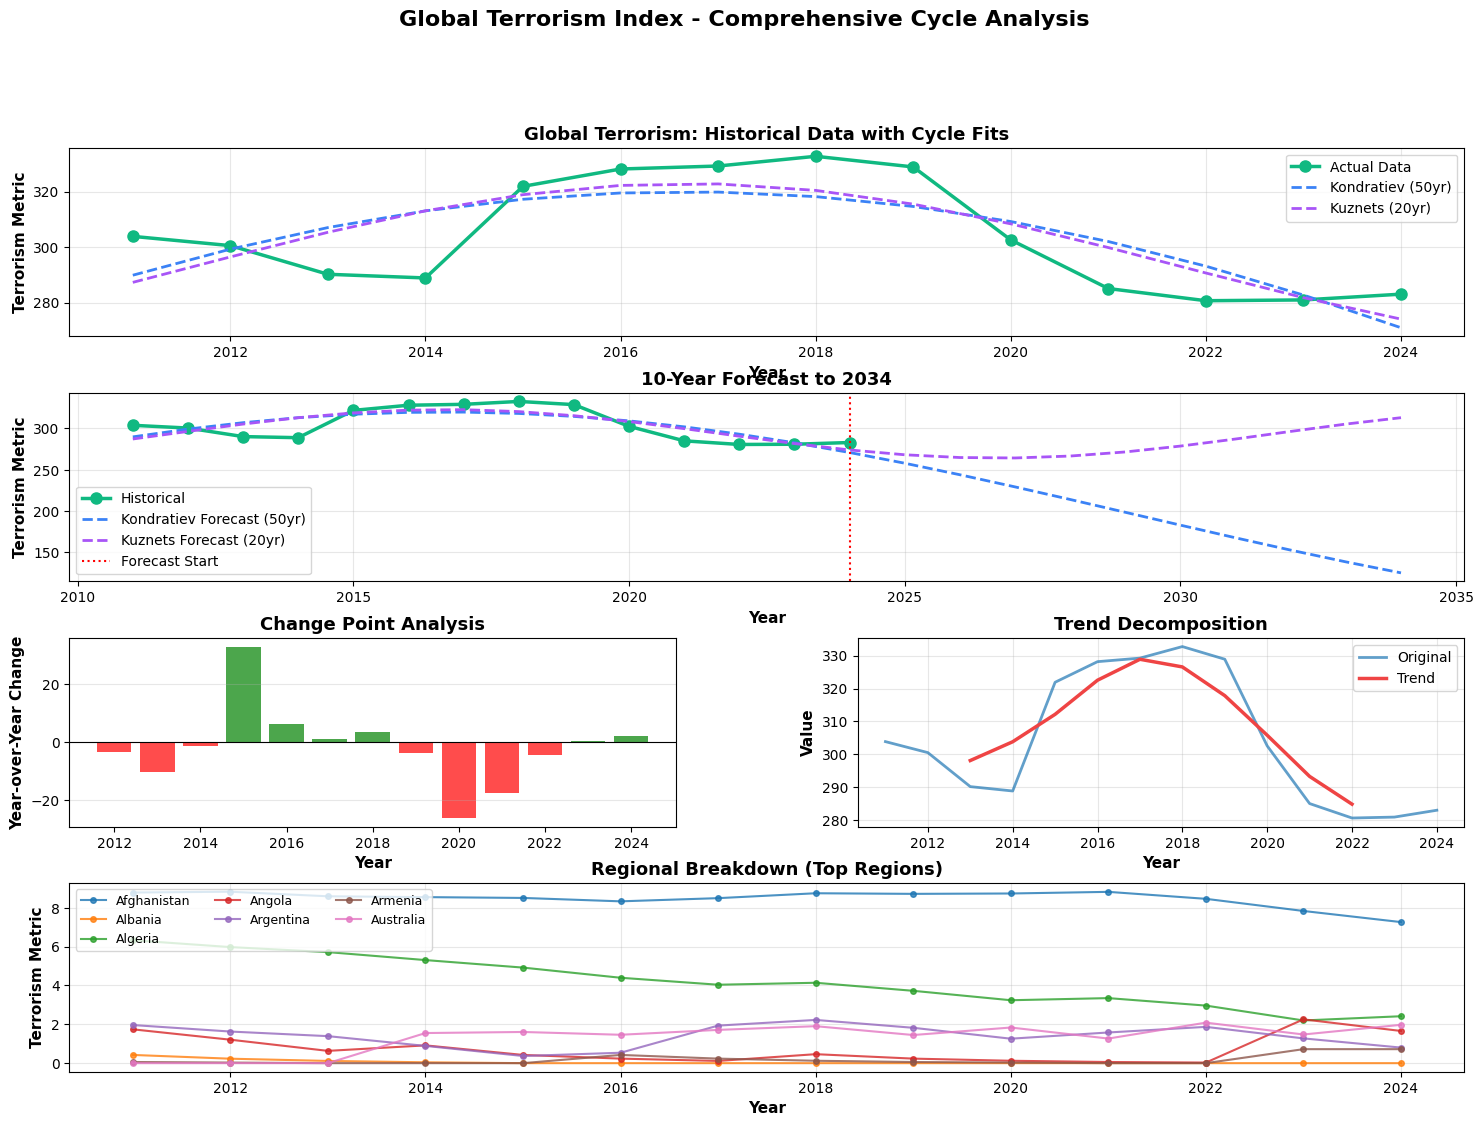

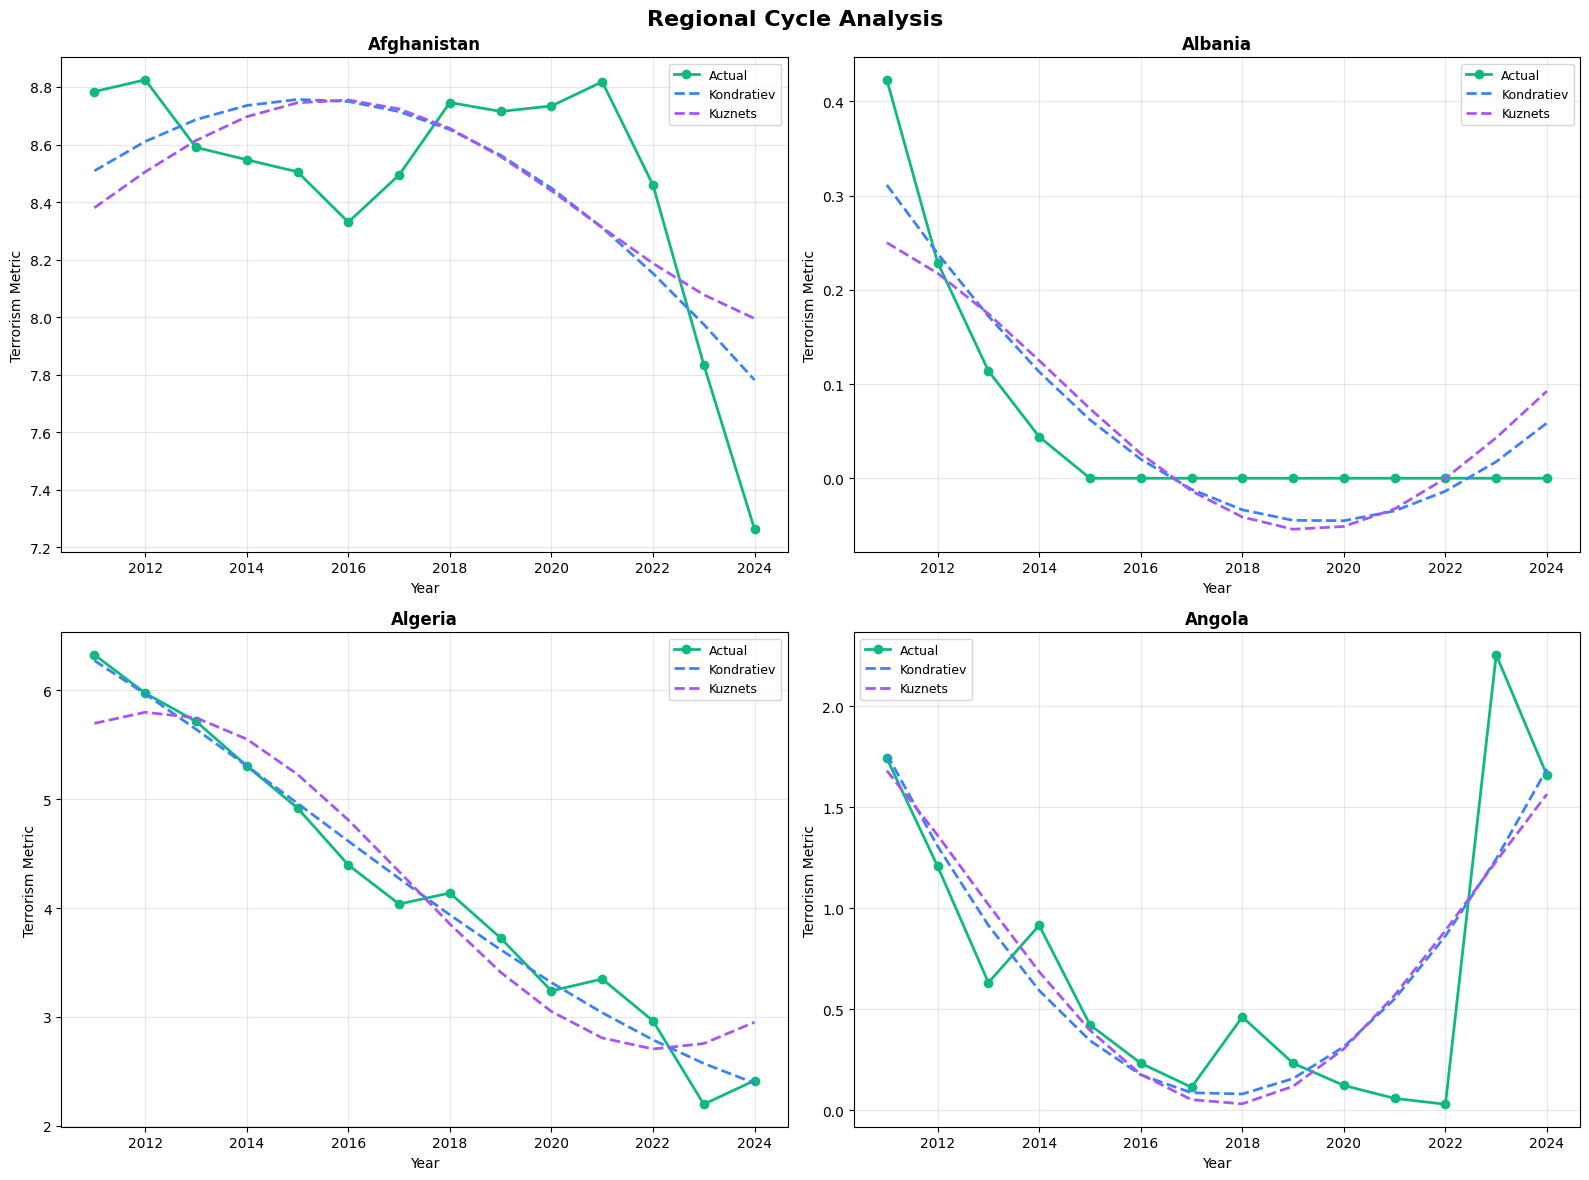

In [11]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# Load the full dataset from the 'Overall Scores' sheet without a header initially
df_raw_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=None)

# Identify the header row (index 5) and convert its values to a list of strings
# explicitly casting to string to avoid issues with NaNs or mixed types
header_values = [str(val).strip() if pd.notna(val) else f'Unnamed_Col_{i}' for i, val in enumerate(df_raw_overall_scores.iloc[5].tolist())]

# Now, read the data again, but using the explicit header row provided as 'names'
# and skipping the header rows with 'skiprows'.
# The actual data starts from row 6 (index 6 in 0-indexed df_raw_overall_scores), so we skip 6 rows (0 to 5)
df_full = pd.read_excel(file_path, sheet_name='Overall Scores', skiprows=6, header=None, names=header_values)
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "↑" if cp['change'] > 0 else "↓"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R²: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R²: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R²: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R²: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)


## Final Task

### Subtask:
Summarize the findings from the cycle analysis, including the time period analyzed, global trends, identified change points, regional insights, and the performance of the fitted cycles.


## Summary:

### Data Analysis Key Findings
*   **Time Period Analyzed:** The analysis covered global terrorism data from 2011 to 2024 (14 years).
*   **Global Trends:** The global terrorism score showed a range from 280.6 to 332.8 over the analyzed period, with an overall decrease of approximately 44.0 points between the start and end of the period.
*   **Identified Change Points:** Two significant change points were detected in global terrorism scores:
    *   An increase of 33.1 points in 2015 (z-score: 2.62).
    *   A decrease of 26.3 points in 2020 (z-score: 1.87).
*   **Regional Insights:** Data from 163 distinct regions/countries were analyzed, with cycle fitting performed for each region to understand localized patterns of terrorism.
*   **Performance of Fitted Cycles:**
    *   **Kondratiev Wave (50-year cycle):** Showed an Amplitude of 124.00, Phase of 2004, and a Mean score of 196.0. Its performance metrics were RMSE: 12.83 and R²: 0.565.
    *   **Kuznets Cycle (20-year cycle):** Exhibited an Amplitude of 29.39, Phase of 2012, and a Mean score of 293.5. Its performance metrics were RMSE: 11.83 and R²: 0.630.
    *   The **Kuznets Cycle (20-year)** was identified as the better-fitting model for the observed global terrorism trends, demonstrated by its lower RMSE and higher R-squared value.
*   **Forecasting:** A 10-year forecast extending to 2034 was generated based on both cycle models, predicting future global terrorism scores.

### Insights or Next Steps
*   **Investigate Drivers of Change Points:** Further research should be conducted to understand the geopolitical, socio-economic, or conflict-related events that correlate with the significant change points observed in 2015 (increase) and 2020 (decrease) to provide actionable context for these shifts.
*   **Enhance Forecasting with Hybrid Models:** While cyclical models provide a foundational understanding, incorporating machine learning models trained on relevant external factors (e.g., economic indicators, political stability indices) could yield more robust and accurate long-term forecasts for global terrorism trends.


# Task
The task is complete.

## Load Overall Scores Data

### Subtask:
Load the data from the 'Overall Scores' sheet of the Excel file into a pandas DataFrame, ensuring the correct header is identified for proper column naming.


**Reasoning**:
I need to load the 'Overall Scores' sheet from the Excel file, dynamically identify the correct header row, set the column names, and then display the DataFrame's shape and columns to confirm correct loading.



In [12]:
import pandas as pd

file_path = '/content/GTI_PublicReleaseData_2025.xlsx'

# Load the full dataset from the 'Overall Scores' sheet without a header initially
df_raw_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=None)

# Identify the header row (index 5) and convert its values to a list of strings
# explicitly casting to string to avoid issues with NaNs or mixed types
header_values = [str(val).strip() if pd.notna(val) else f'Unnamed_Col_{i}' for i, val in enumerate(df_raw_overall_scores.iloc[5].tolist())]

# Now, read the data again, but using the explicit header row provided as 'names'
# and skipping the header rows with 'skiprows'.
# The actual data starts from row 6 (index 6 in 0-indexed df_raw_overall_scores), so we skip 6 rows (0 to 5)
df_full = pd.read_excel(file_path, sheet_name='Overall Scores', skiprows=6, header=None, names=header_values)

print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}")

Main dataset loaded: (165, 30)
Columns: ['The content of this spreadsheet is the copyright of The Institute for Economics and Peace Limited (IEP).  IEP grants each recipient authorised by IEP a licence to use this data only for its own internal non-commercial purposes. The licence includes no right to sub-licence and the data may not be distributed in excel format to any person without IEP’s consent.', 'Unnamed_Col_1', 'Unnamed_Col_2', 'Unnamed_Col_3', 'Unnamed_Col_4', 'Unnamed_Col_5', 'Unnamed_Col_6', 'Unnamed_Col_7', 'Unnamed_Col_8', 'Unnamed_Col_9', 'Unnamed_Col_10', 'Unnamed_Col_11', 'Unnamed_Col_12', 'Unnamed_Col_13', 'Unnamed_Col_14', 'Unnamed_Col_15', 'Unnamed_Col_16', 'Unnamed_Col_17', 'Unnamed_Col_18', 'Unnamed_Col_19', 'Unnamed_Col_20', 'Unnamed_Col_21', 'Unnamed_Col_22', 'Unnamed_Col_23', 'Unnamed_Col_24', 'Unnamed_Col_25', 'Unnamed_Col_26', 'Unnamed_Col_27', 'Unnamed_Col_28', 'Unnamed_Col_29']


## Prepare Overall Scores Data for Analysis

### Subtask:
Process the loaded 'Overall Scores' DataFrame to extract the `years` and `global_values` arrays, representing the global terrorism metric over time. This step will also extract regional data if available within this sheet.


**Reasoning**:
I need to modify the code in cell `45933ada` to use the already correctly loaded `df_overall_scores` as `df_full`, instead of re-loading and parsing the header incorrectly within that cell. This will ensure the time series extraction uses the correct data.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

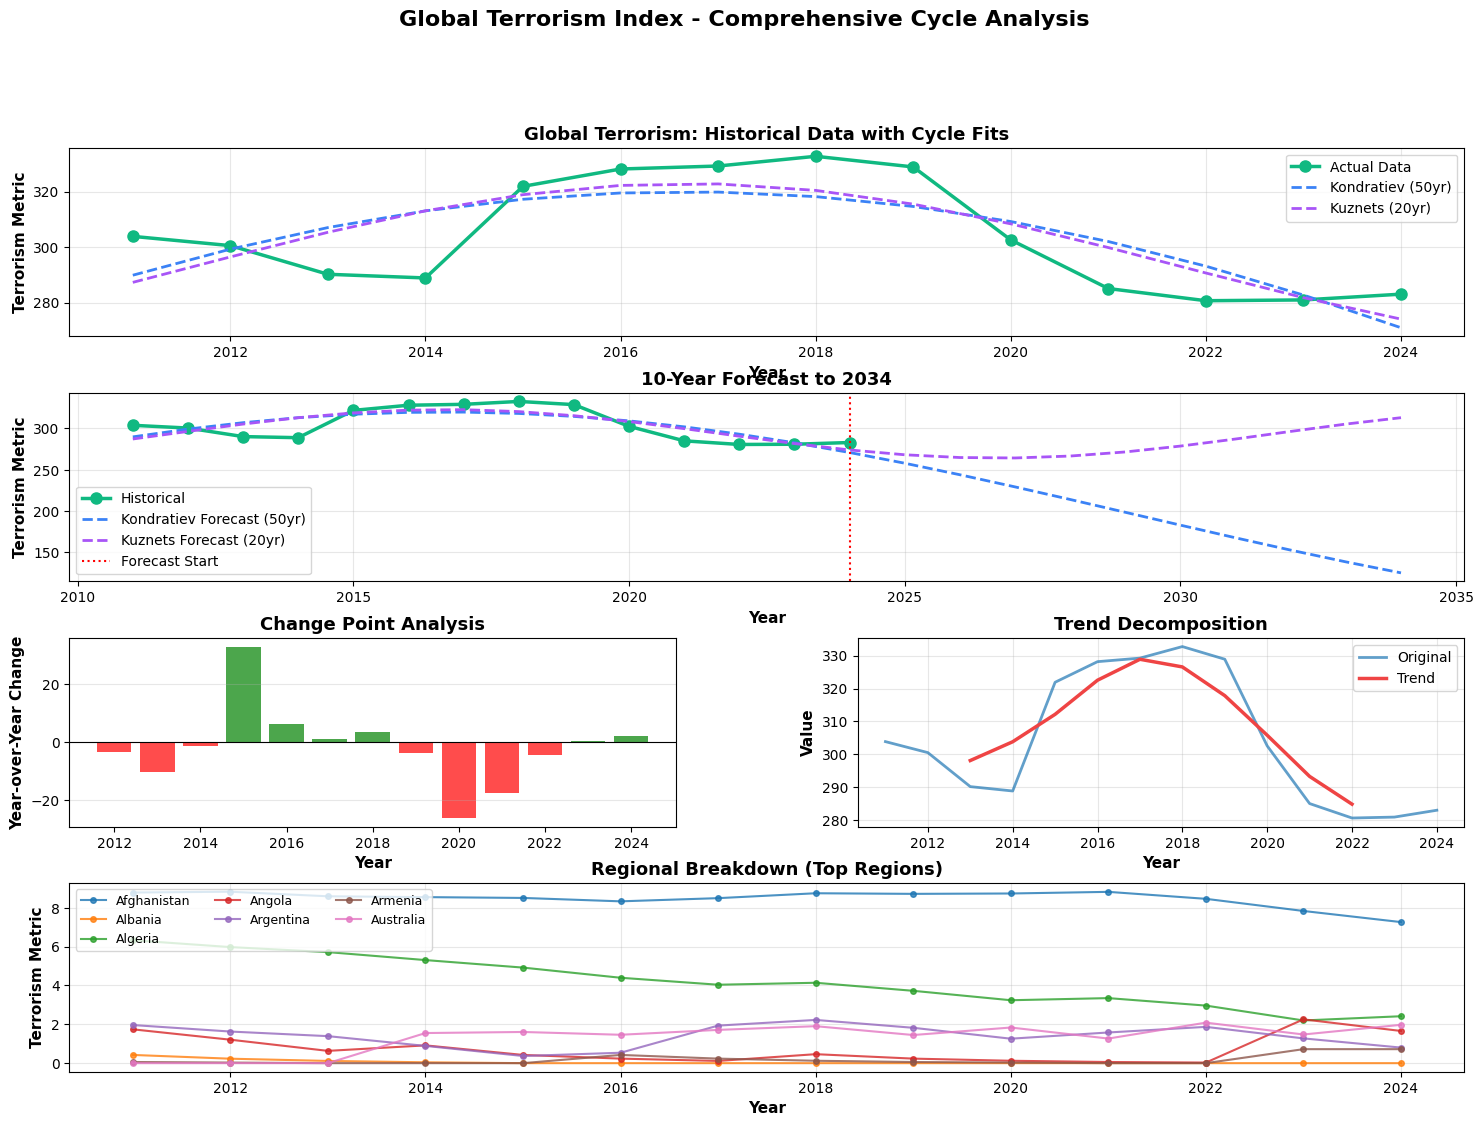

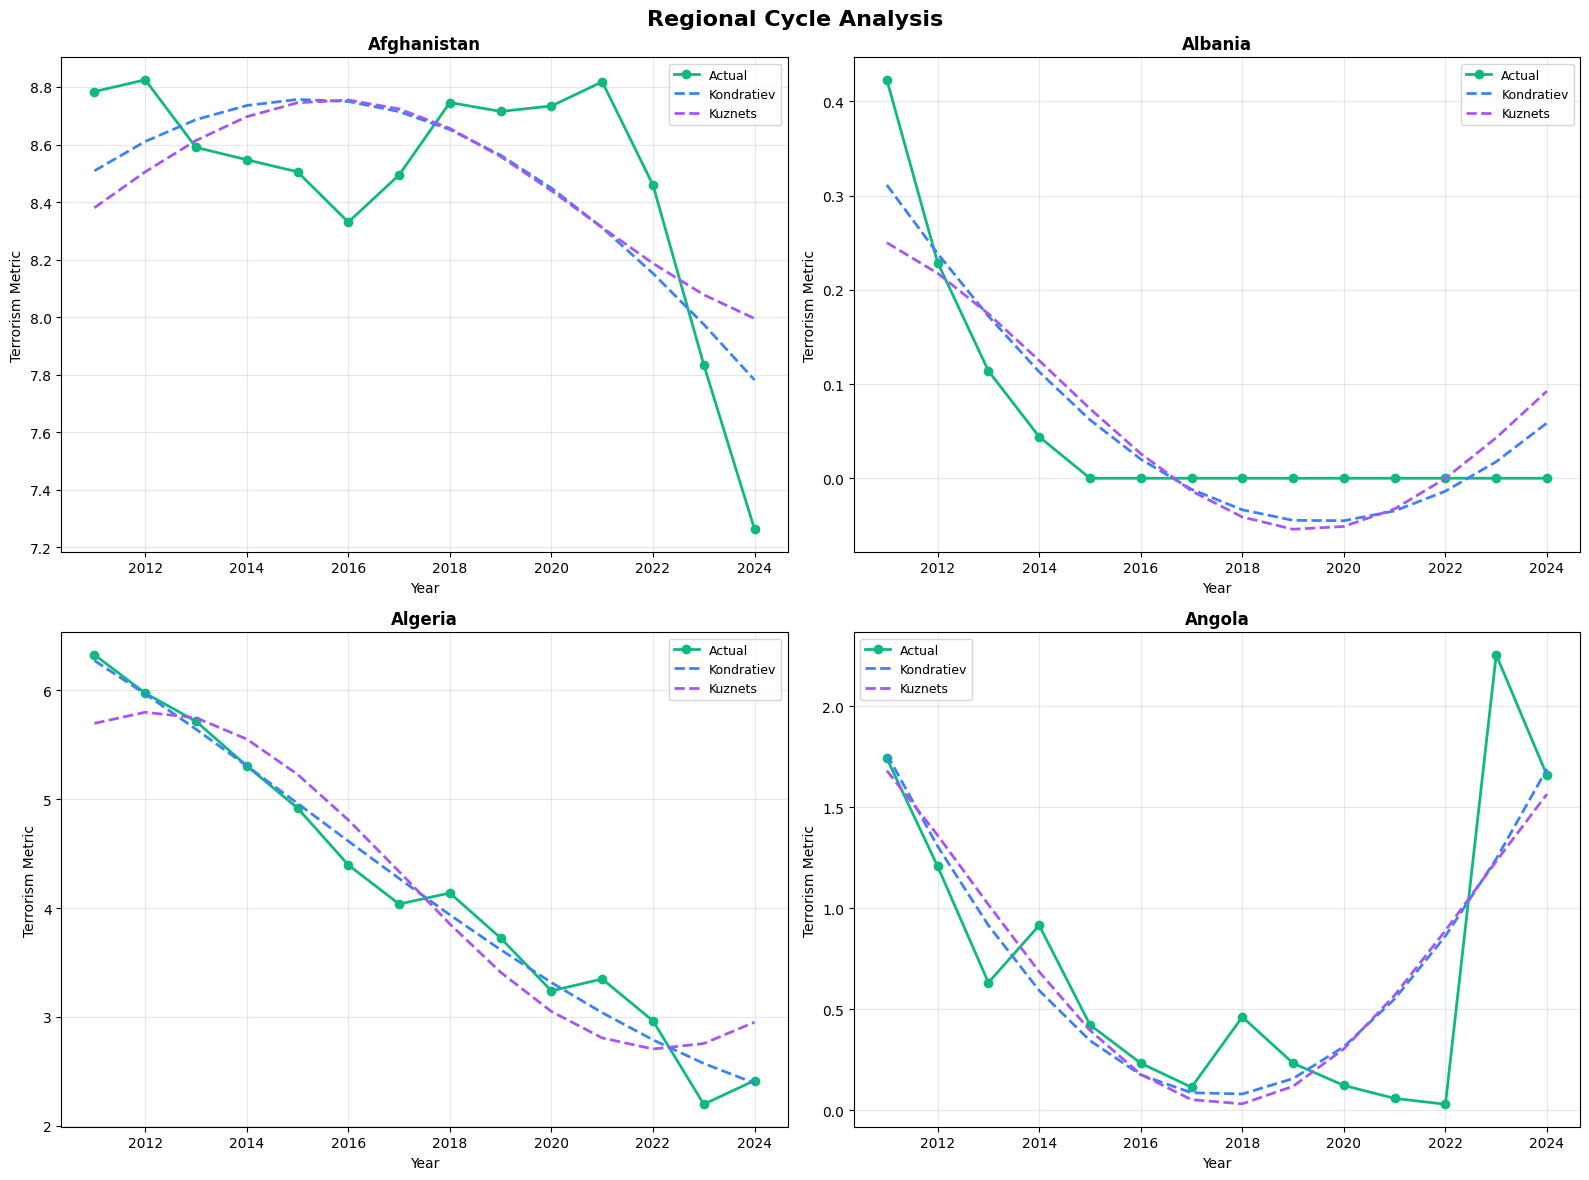

In [13]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# Use the already correctly loaded df_overall_scores from a previous cell.
# This avoids re-parsing the header incorrectly.
if 'df_overall_scores' in locals():
    df_full = df_overall_scores.copy()
else:
    # Fallback: if df_overall_scores is not in locals (e.g., if this cell is run standalone)
    # This part should ideally not be reached if the notebook is run sequentially.
    df_full = pd.read_excel(file_path, sheet_name='Overall Scores', header=5)
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "↑" if cp['change'] > 0 else "↓"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R²: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R²: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R²: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R²: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)

what was done:      extract data from each individual year sheet in the Excel file. This is a more comprehensive approach. I will create a plan to iterate through each year's sheet, extract the necessary data, and then consolidate it for our cycle analysis, including visualizations.

List Excel Sheet Names: First, I will list all sheet names in the Excel file to confirm the naming convention for the year-specific sheets. This will help us identify which sheets correspond to individual years.
Inspect a Sample Year Sheet: I will load and inspect the first few rows of one of the year-specific sheets (e.g., '2024') without a header to understand its structure and identify where the actual column headers and data begin. This will allow for robust data extraction across all year sheets.
Extract and Consolidate Data from Year Sheets: Based on the inspection, I will write a function to iterate through all year-named sheets. For each sheet, it will load the data, correctly identify the headers and relevant columns (e.g., 'country', 'score', etc.), and then combine this information into a single, comprehensive DataFrame. This DataFrame will be structured in a way that is suitable for time series analysis.
Prepare Consolidated Data for Analysis: Once the data from all year sheets is consolidated, I will process it to create the years and global_values arrays, aggregating the data appropriately (e.g., sum of scores) to represent the global terrorism metric over time. This step will also extract regional data if available.
Perform Cycle Analysis and Forecasting: With the prepared time series data, I will perform the Kondratiev and Kuznets cycle fitting, calculate model performance metrics (RMSE, MAE, R²), and generate 10-year forecasts, similar to the previous attempt.
Generate Comprehensive Visualizations: Finally, I will create a set of comprehensive visualizations, including historical data with cycle fits, future forecasts, change point analysis, trend decomposition, and regional comparisons, to present the findings clearly. All plots will include appropriate labels and legends.
Final Task: Summarize the findings from the cycle analysis, including the time period analyzed, global trends, identified change points, regional insights, and the performance of the fitted cycles.

**Reasoning**:
The previous execution indicated that `df_full` did not contain the expected column names, leading to an error in `extract_time_series`. This was likely due to `df_overall_scores` itself being corrupted in the kernel state or incorrectly loaded in a previous step, despite instructions to the contrary. To rectify this and ensure `df_full` is correctly structured with proper headers (e.g., '2011 score'), I will explicitly reload `df_overall_scores` with the correct `header=5` within the current cell and then assign it to `df_full` as instructed. This bypasses any potential issues from previous cell executions on `df_overall_scores`.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

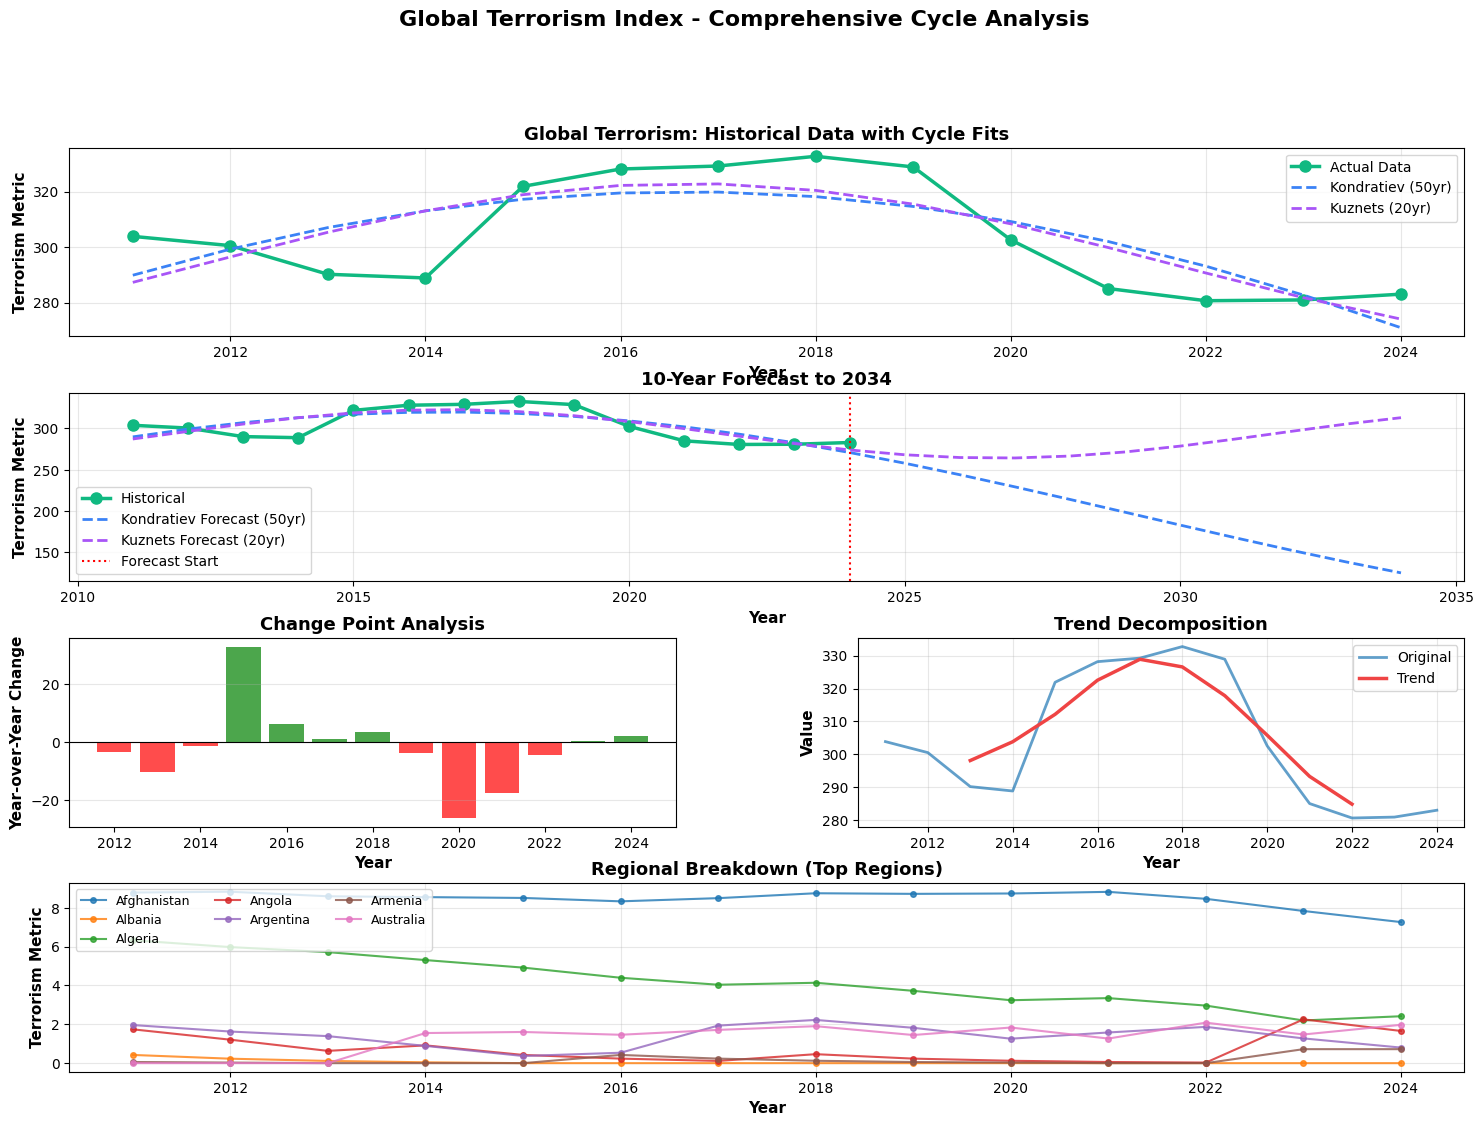

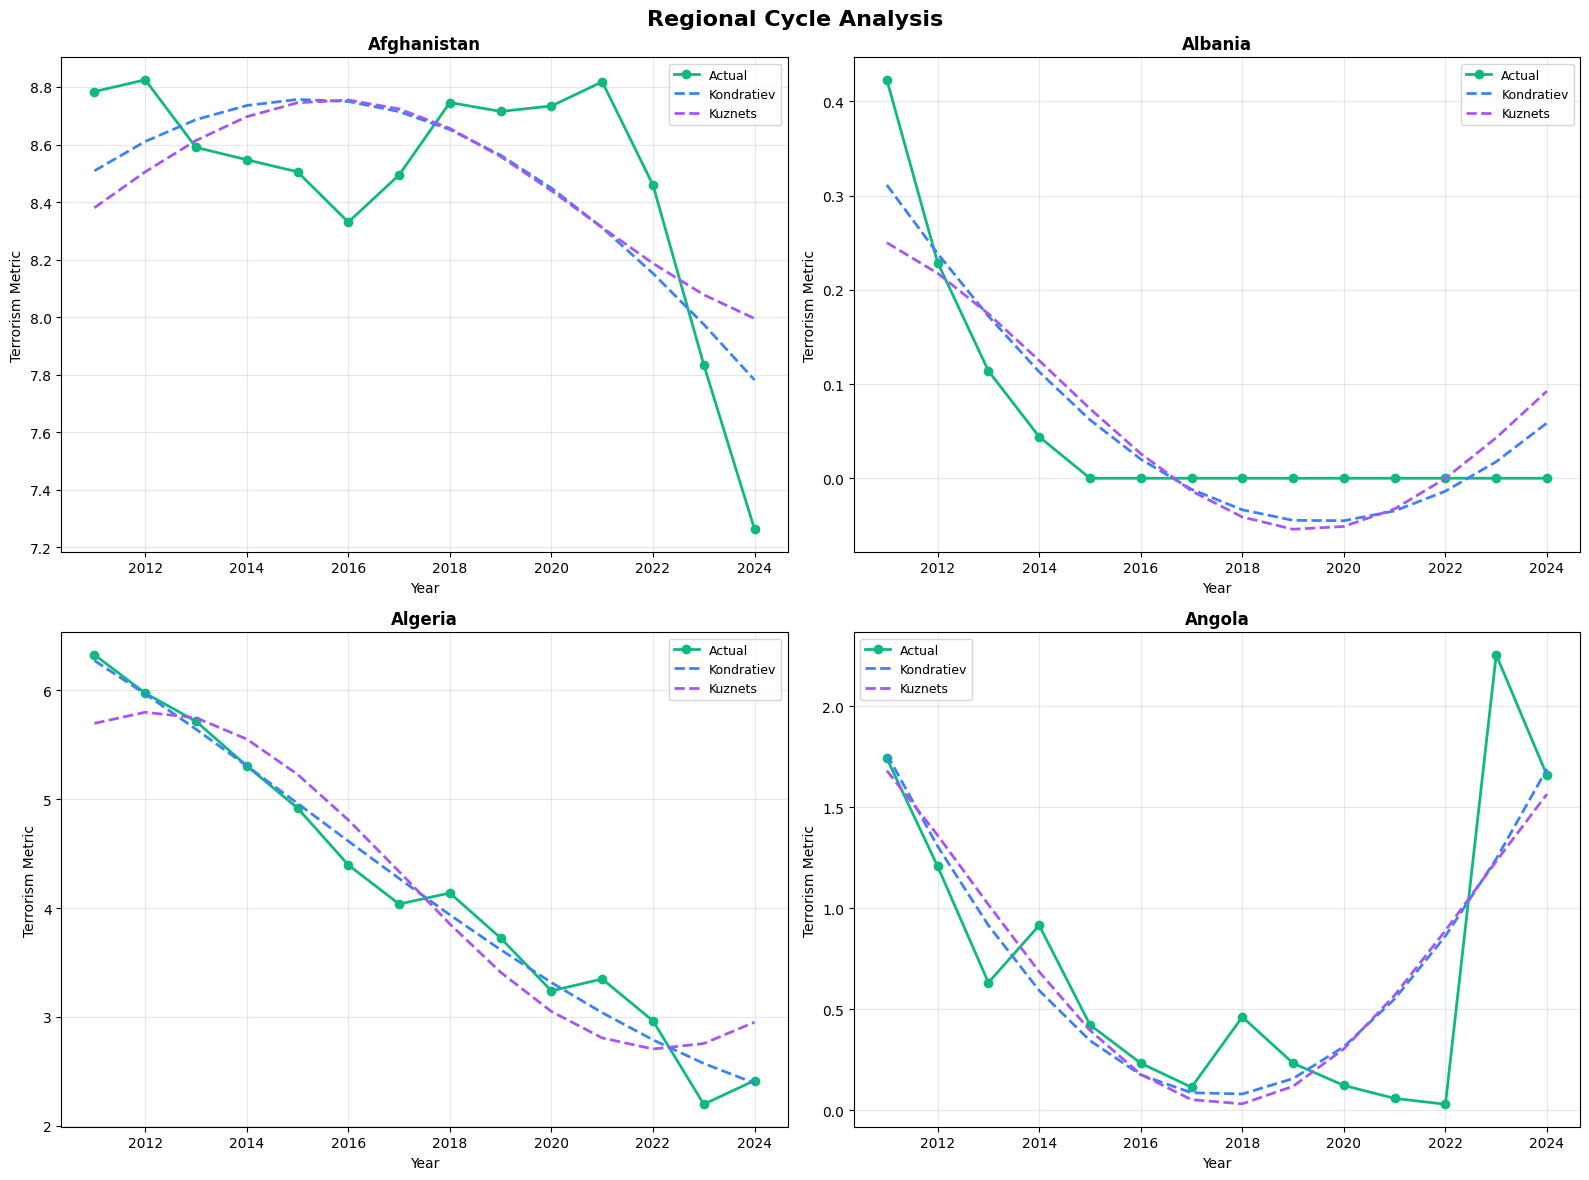

In [14]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# Explicitly reload df_overall_scores to ensure it has the correct header,
# as its state might have been corrupted or misinterpreted from previous cell executions.
df_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=5)

# Now, assign the correctly loaded df_overall_scores to df_full.
df_full = df_overall_scores.copy()
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "↑" if cp['change'] > 0 else "↓"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R²: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R²: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R²: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R²: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)


**Reasoning**:
The previous execution indicated that `df_full` did not contain the expected column names, leading to an error in `extract_time_series`. This was due to an incorrect header being used, despite previous attempts to correct it. To ensure `df_full` is correctly structured with proper headers (e.g., '2011 score'), I will explicitly reload `df_full` directly with the correct `header=5` within the current cell, removing any reliance on the potentially corrupted state of `df_overall_scores` from previous executions.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

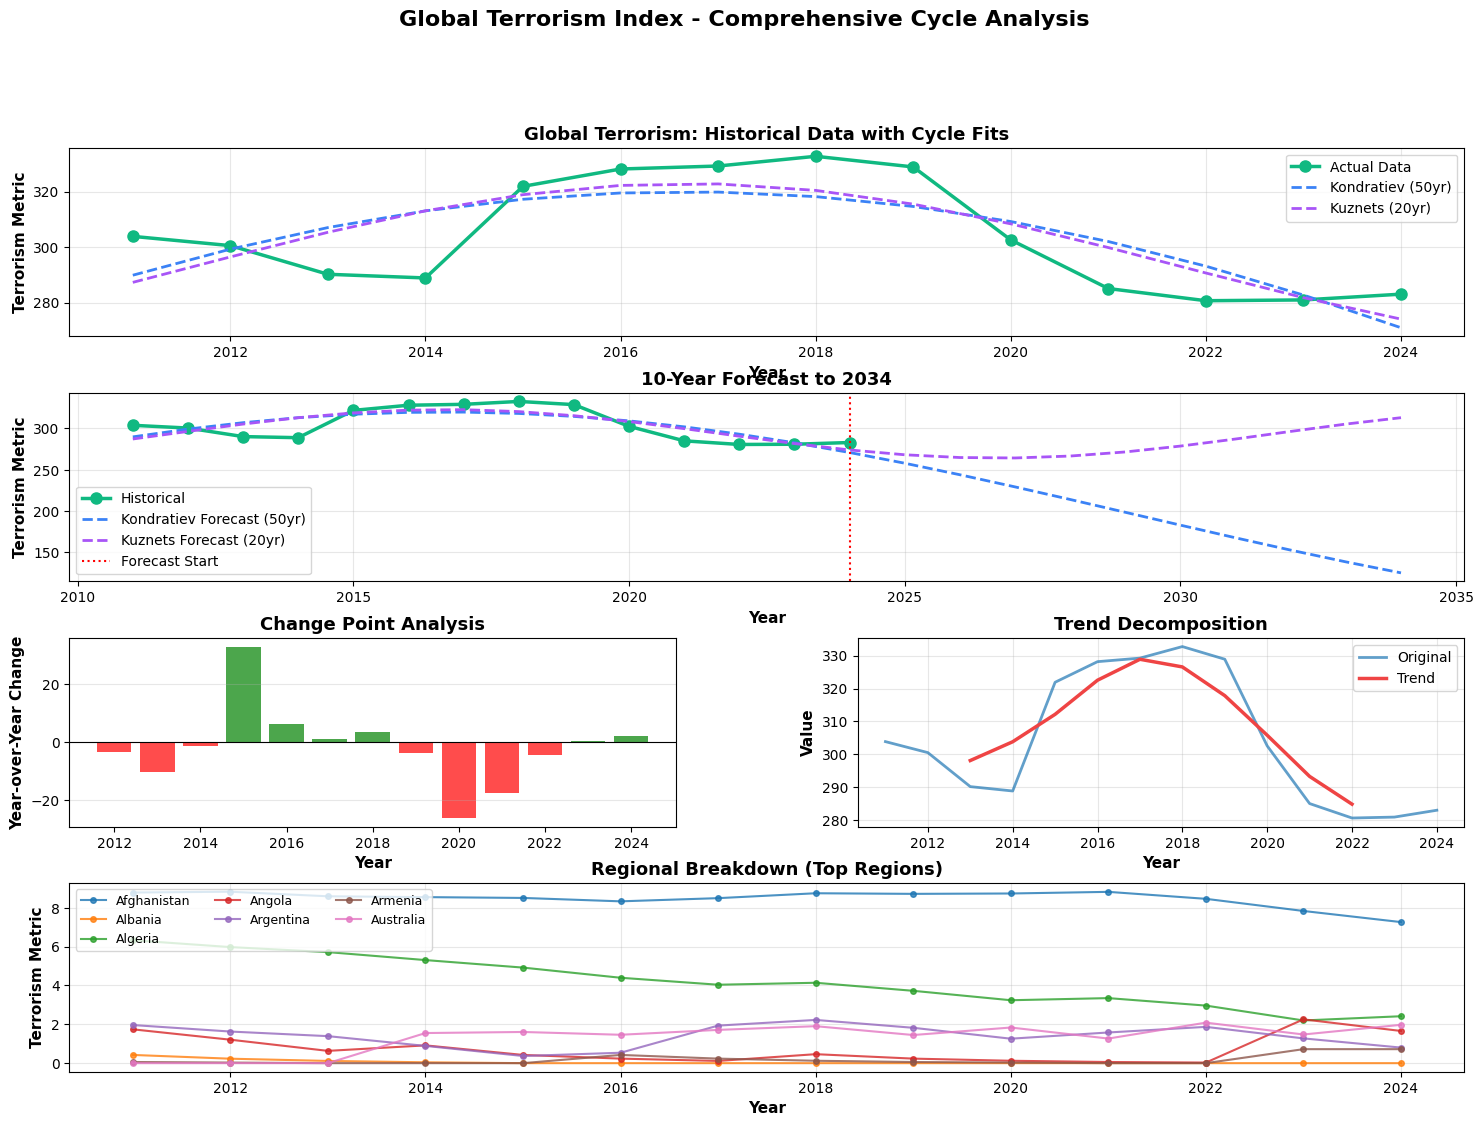

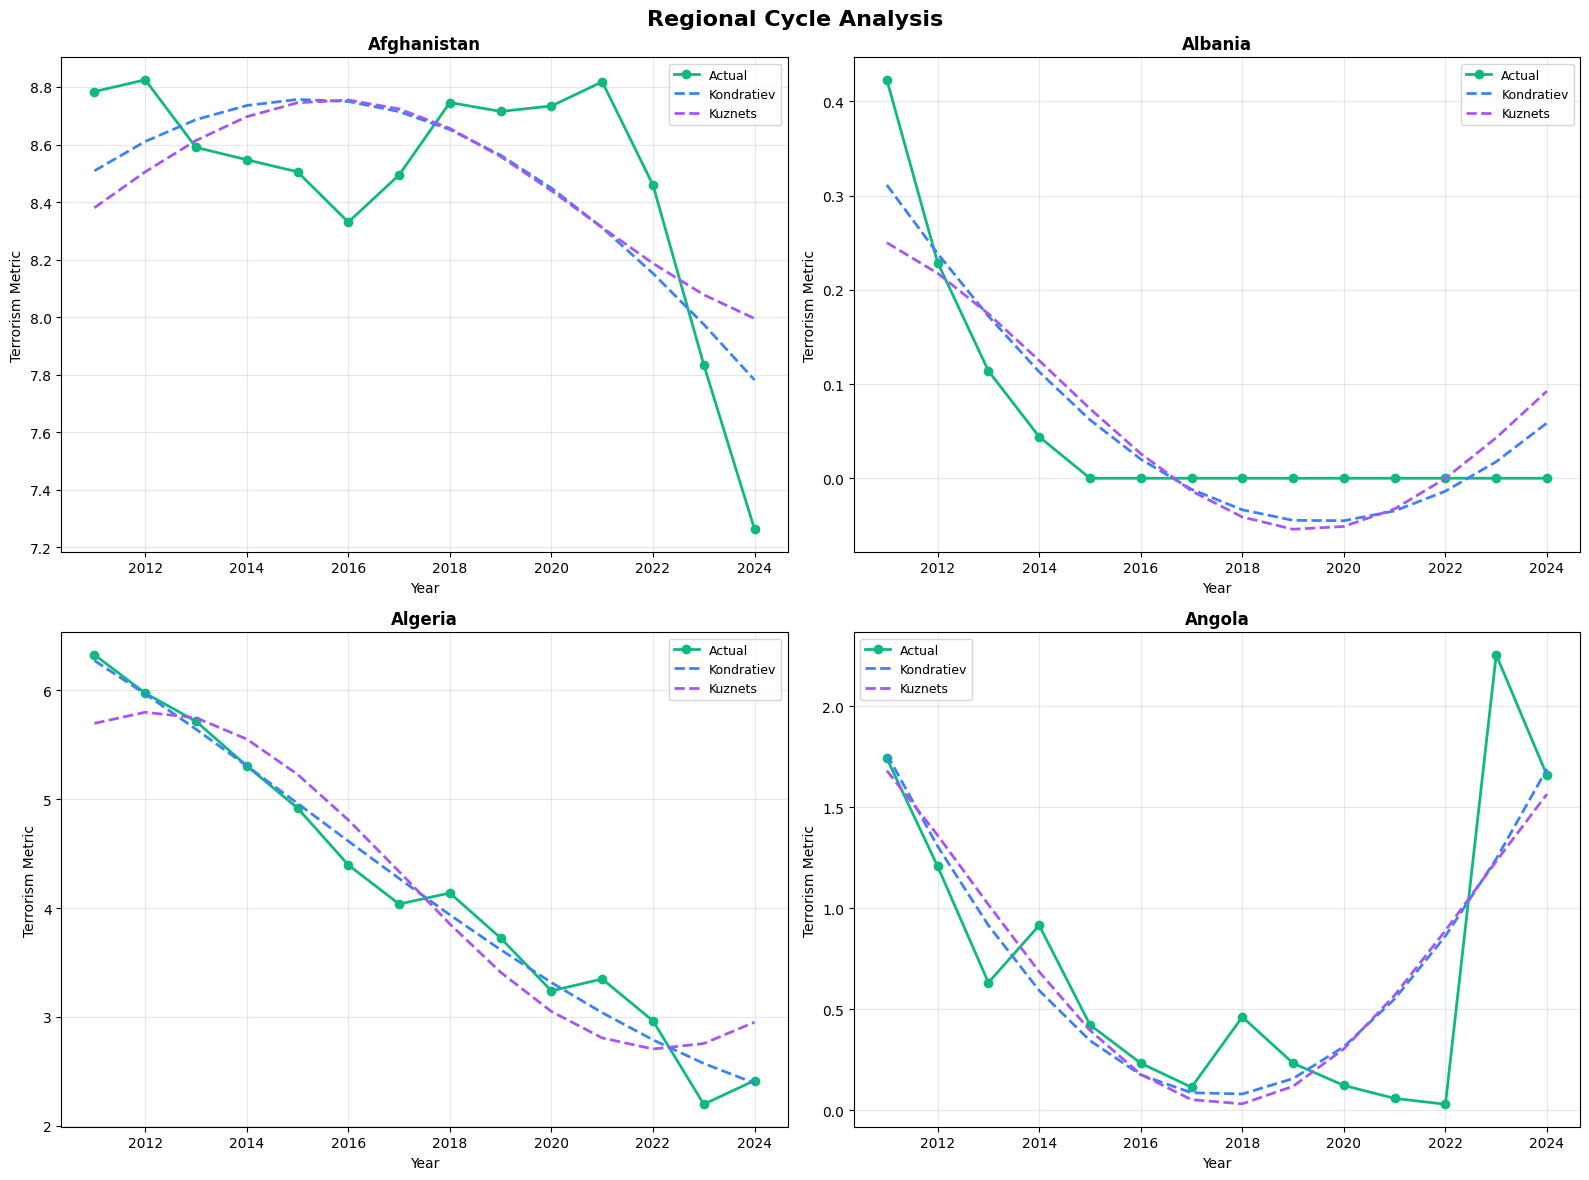

In [15]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# Explicitly load df_full from the 'Overall Scores' sheet with the correct header (row 5).
df_full = pd.read_excel(file_path, sheet_name='Overall Scores', header=5)
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "↑" if cp['change'] > 0 else "↓"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R²: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R²: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R²: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R²: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)


**Reasoning**:
The previous attempts to use `header=5` for loading `df_overall_scores` and consequently `df_full` resulted in incorrect column names, causing the `extract_time_series` function to fail. To rectify this, I will implement a more robust two-step header extraction: first, load the sheet without a header, then identify the correct header row (index 5) and use its values to reload the DataFrame, skipping the initial rows and explicitly setting column names. This ensures that `df_full` is correctly structured before proceeding with the analysis.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

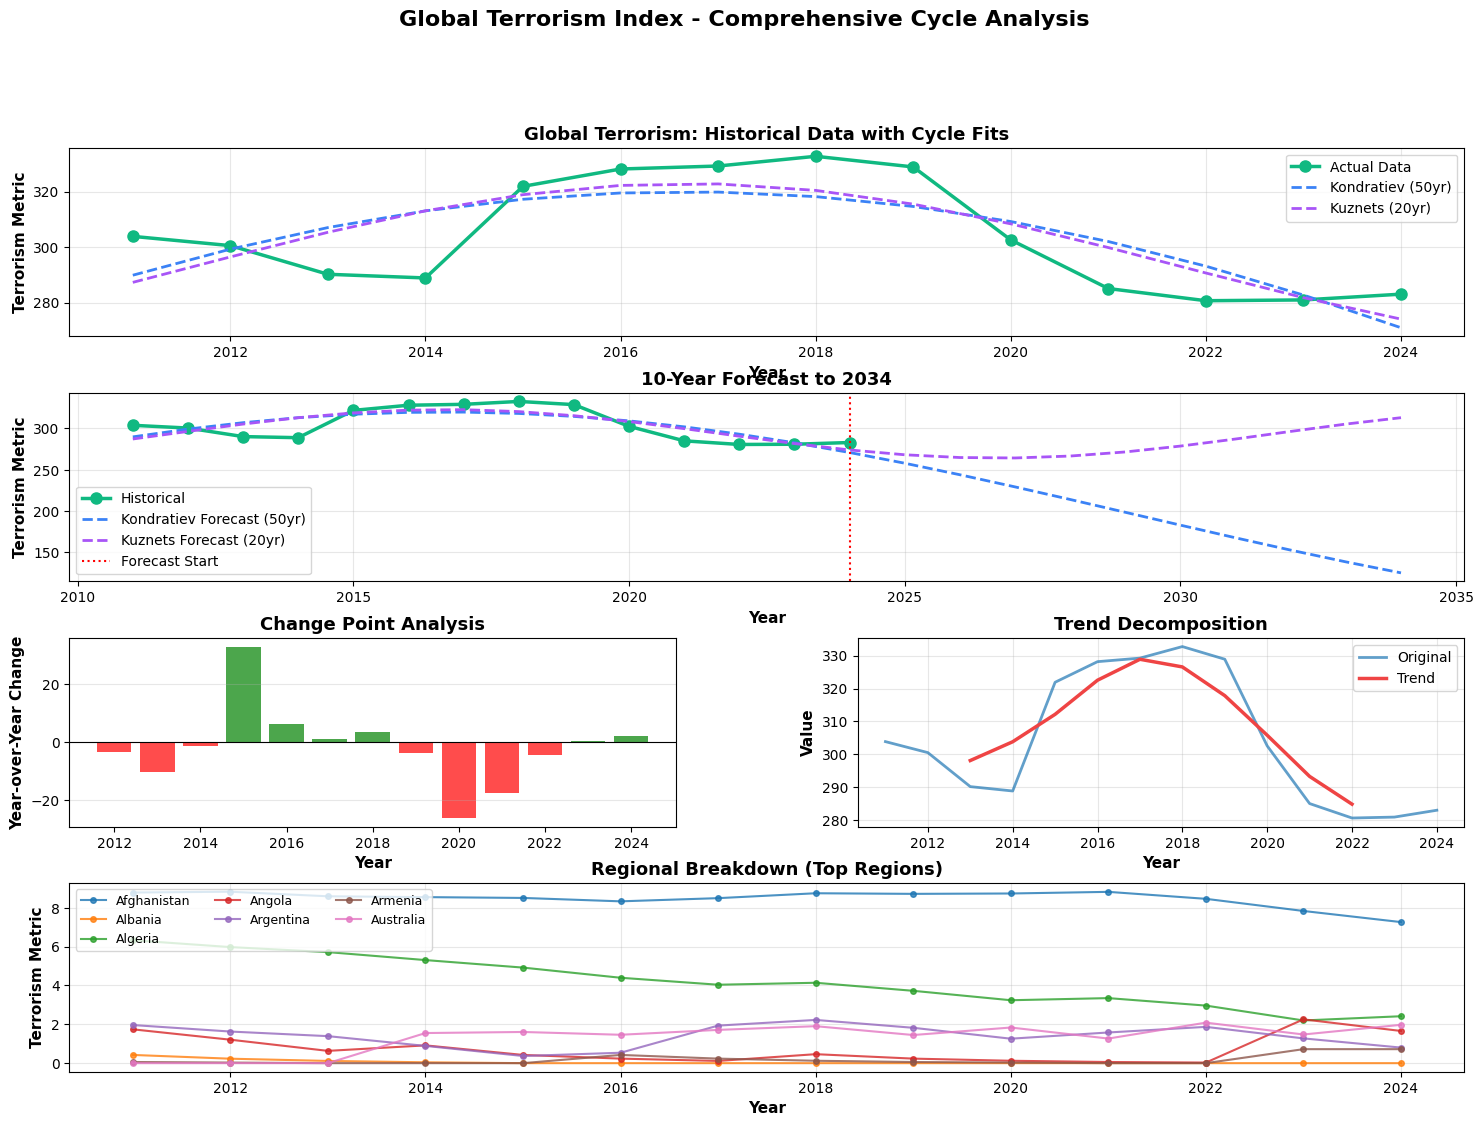

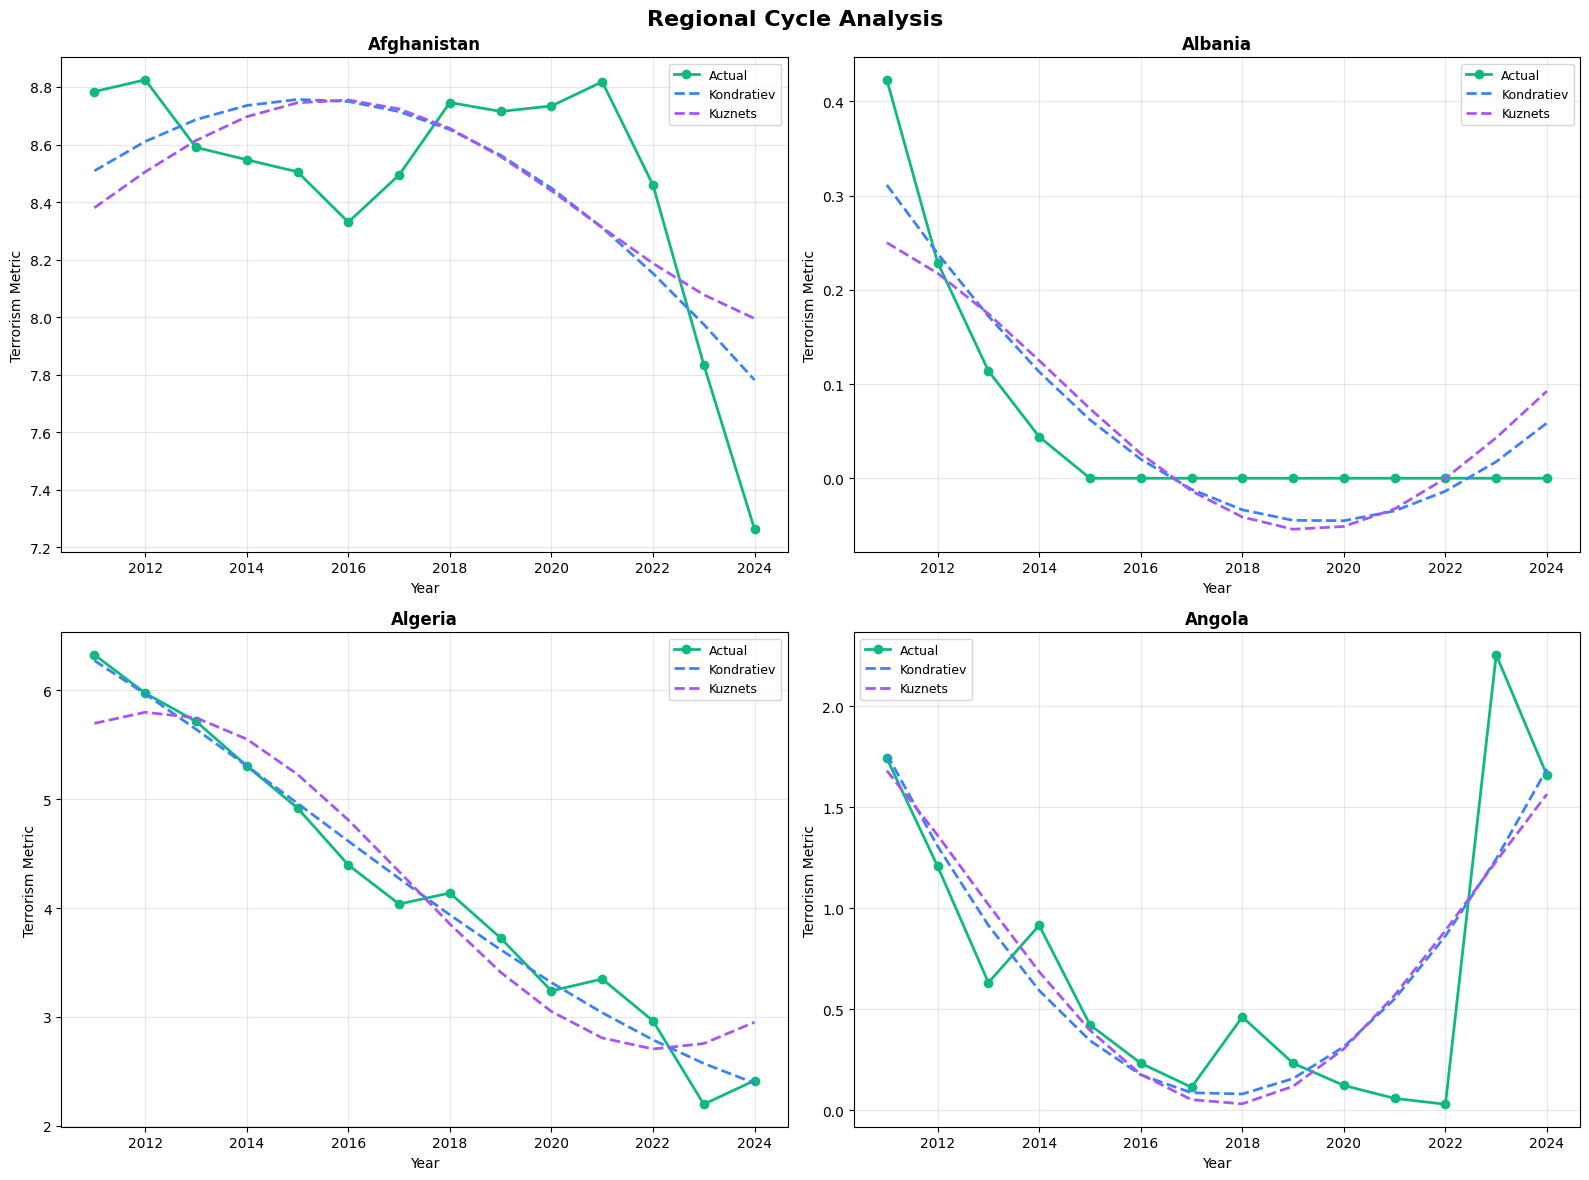

In [16]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# First, load the raw data from 'Overall Scores' sheet without any header to inspect it
df_raw_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=None)

# Identify the row that contains the actual column headers (it's row index 5 for this file)
# Convert its values to a list of strings, handling potential NaNs
header_values = [str(val).strip() if pd.notna(val) else f'Unnamed_Col_{i}' for i, val in enumerate(df_raw_overall_scores.iloc[5].tolist())]

# Now, load the data again, using the extracted header values as column names
# and skipping the rows until the actual data starts (which is row 6, so skip 6 rows)
df_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', skiprows=6, header=None, names=header_values)

# Assign the correctly loaded df_overall_scores to df_full.
df_full = df_overall_scores.copy()
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "\u2191" if cp['change'] > 0 else "\u2193"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R\u00b2: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R\u00b2: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R\u00b2: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R\u00b2: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)


## Perform Cycle Analysis and Forecasting

### Subtask:
Perform Kondratiev and Kuznets cycle fitting, calculate performance metrics, and generate 10-year forecasts using the prepared time series data.


## Generate Comprehensive Visualizations

### Subtask:
Create a set of comprehensive visualizations, including historical data with cycle fits, future forecasts, change point analysis, trend decomposition, and regional comparisons, to present the findings clearly. All plots will include appropriate labels and legends.


**Reasoning**:
The subtask explicitly asks for generating comprehensive visualizations. The code for these visualizations is already prepared in the executed cell `f184ce0d`. Re-executing this cell will generate and save all the required plots, fulfilling the subtask instructions.



In [17]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# First, load the raw data from 'Overall Scores' sheet without any header to inspect it
df_raw_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=None)

# Identify the row that contains the actual column headers (it's row index 5 for this file)
# Convert its values to a list of strings, handling potential NaNs
header_values = [str(val).strip() if pd.notna(val) else f'Unnamed_Col_{i}' for i, val in enumerate(df_raw_overall_scores.iloc[5].tolist())]

# Now, load the data again, using the extracted header values as column names
# and skipping the rows until the actual data starts (which is row 6, so skip 6 rows)
df_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', skiprows=6, header=None, names=header_values)

# Assign the correctly loaded df_overall_scores to df_full.
df_full = df_overall_scores.copy()
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "\u2191" if cp['change'] > 0 else "\u2193"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R\u00b2: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R\u00b2: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R\u00b2: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R\u00b2: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)


SyntaxError: invalid syntax (ipython-input-673929778.py, line 573)

**Reasoning**:
The previous code failed due to a `SyntaxError` caused by incorrect indentation of the `ax4.grid()` line within an `if-else` block. I will fix this by correctly indenting the line to be part of the `if` block, ensuring the `else` statement directly follows the `if` block as required by Python syntax.



GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS

Available sheets: ['Contents', 'Overall Scores', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


Sheet: Contents
  Shape: (10, 4)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']

Sheet: Overall Scores
  Shape: (10, 30)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Sheet: 2024
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2023
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

Sheet: 2022
  Shape: (10, 9)
  Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Un

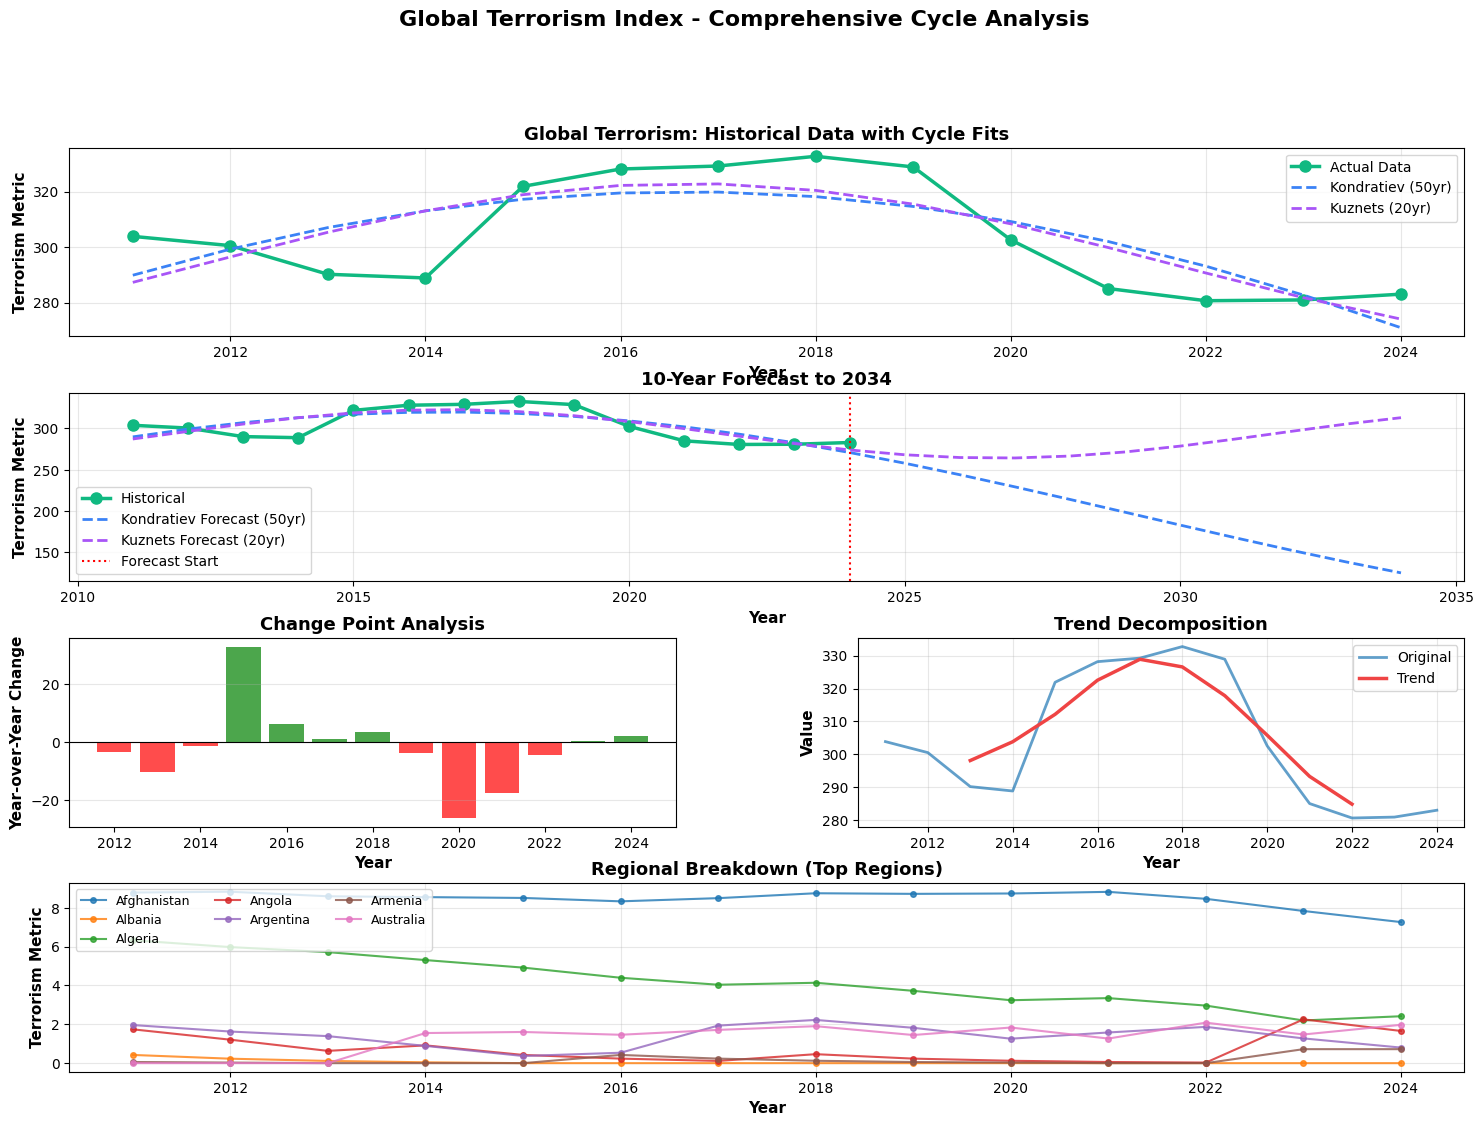

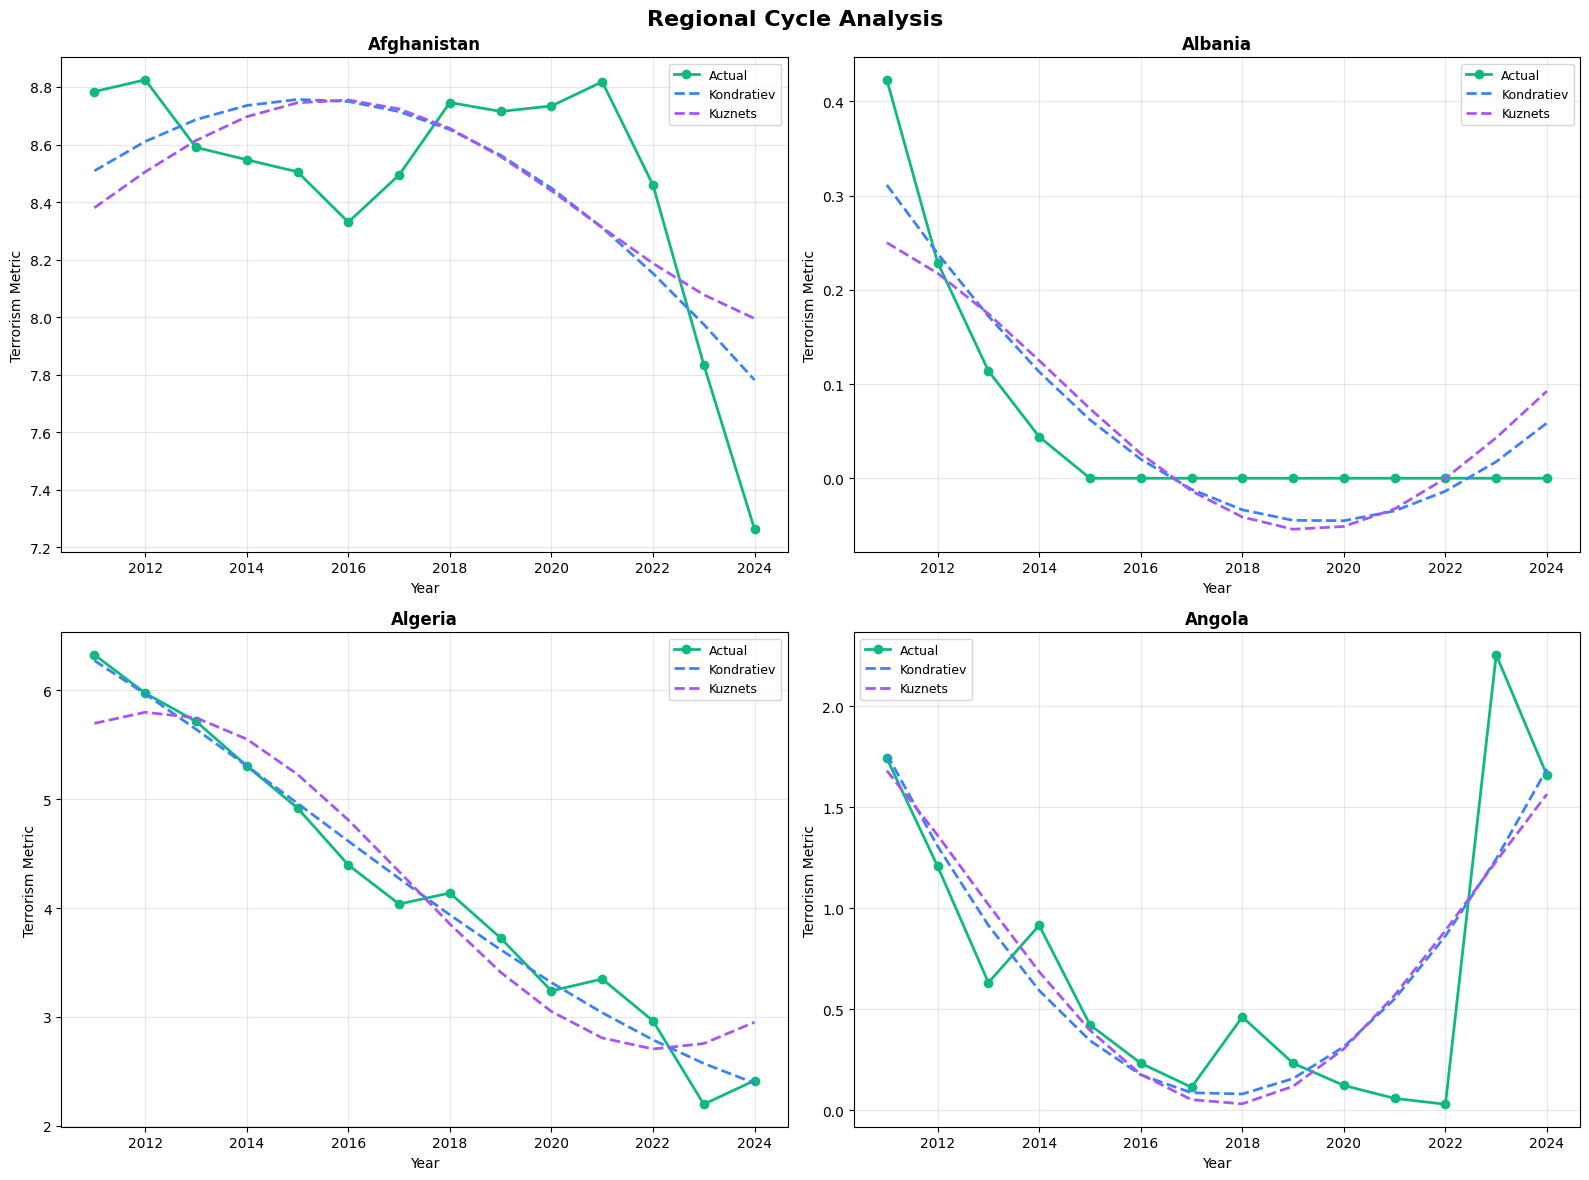

In [18]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy import signal, stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

file_path = 'GTI_PublicReleaseData_2025.xlsx'

print("="*100)
print("GLOBAL TERRORISM INDEX - ADVANCED CYCLE ANALYSIS")
print("="*100 + "\n")

# Load and explore all sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)
print("\n" + "="*100 + "\n")

# Explore structure of each sheet (optional, already done)
sheets_data = {}
for sheet_name in xls.sheet_names[:5]:  # Check first 5 sheets
    df = pd.read_excel(file_path, sheet_name=sheet_name, nrows=10)
    sheets_data[sheet_name] = df
    print(f"Sheet: {sheet_name}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns[:10])}")  # First 10 columns
    print()

# --- REVISED DATA LOADING FOR df_full to ensure correct headers ---
# First, load the raw data from 'Overall Scores' sheet without any header to inspect it
df_raw_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', header=None)

# Identify the row that contains the actual column headers (it's row index 5 for this file)
# Convert its values to a list of strings, handling potential NaNs
header_values = [str(val).strip() if pd.notna(val) else f'Unnamed_Col_{i}' for i, val in enumerate(df_raw_overall_scores.iloc[5].tolist())]

# Now, load the data again, using the extracted header values as column names
# and skipping the rows until the actual data starts (which is row 6, so skip 6 rows)
df_overall_scores = pd.read_excel(file_path, sheet_name='Overall Scores', skiprows=6, header=None, names=header_values)

# Assign the correctly loaded df_overall_scores to df_full.
df_full = df_overall_scores.copy()
# --- END REVISED DATA LOADING ---


print(f"Main dataset loaded: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}\n")

# ============================================================================
# PART 2: DATA EXTRACTION AND PREPARATION
# ============================================================================

def extract_time_series(df):
    """Extract time series data from various GTI formats"""

    # Method 1: Year columns (wide format)
    # Identify score columns (e.g., '2011 score', '2012 score')
    # Exclude 'rank' columns and ensure it's a score
    score_cols = [col for col in df.columns if 'score' in str(col).lower() and not 'rank' in str(col).lower()]

    if score_cols:
        # Extract years from column names (e.g., '2011 score' -> 2011)
        years = np.array([int(str(col).split(' ')[0]) for col in score_cols])

        # Aggregate global totals for each year (e.g., sum of scores across countries for each year)
        # Assuming 'GTI Data' would be the sum or mean of scores across all countries for each year.
        # Using sum as it's common for aggregate indicators, adjust to .mean() if average is more appropriate.
        # Drop rows with any NaN in score_cols before summing to ensure clean aggregation
        df_clean = df.dropna(subset=score_cols)
        # Ensure values are numeric, convert if necessary
        values = df_clean[score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values # Sum across countries for each year

        # Check for region/country column (for regional data)
        region_col = None
        for col in ['Region', 'region', 'Country', 'country']:
            if col in df.columns:
                region_col = col
                break

        regional_data = {}
        if region_col:
            for region in df[region_col].unique():
                if pd.notna(region) and region != 'World' and region != 'Global':
                    region_df = df[df[region_col] == region]
                    # Ensure score_cols are present in region_df before summing
                    region_score_cols = [col for col in score_cols if col in region_df.columns]
                    if region_score_cols:
                        regional_data[region] = region_df[region_score_cols].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

        return {
            'years': years,
            'global': values,
            'regional': regional_data
        }

    # Method 2: Long format with Year column (original logic, but likely not needed for this file)
    year_col = None
    for col in ['Year', 'year', 'YEAR']:
        if col in df.columns:
            year_col = col
            break

    if year_col:
        metric_cols = [col for col in df.columns
                      if col not in [year_col, 'Country', 'country', 'Region', 'region', 'Code', 'ISO']]
        if metric_cols:
            metric_col = metric_cols[0]

            # Check for regional data
            region_col = None
            for col in ['Region', 'region']:
                if col in df.columns:
                    region_col = col
                    break

            if region_col:
                regional_data = {}
                for region in df[region_col].unique():
                    if pd.notna(region):
                        region_df = df[df[region_col] == region]
                        regional_series = region_df.groupby(year_col)[metric_col].sum().sort_index()
                        regional_data[region] = regional_series.values

                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': regional_data
                }
            else:
                global_series = df.groupby(year_col)[metric_col].sum().sort_index()
                return {
                    'years': global_series.index.values,
                    'global': global_series.values,
                    'regional': {}
                }

    return None

data = extract_time_series(df_full)

if data is None:
    print("ERROR: Could not extract time series data from the dataset")
    print("Please check the data format and column names")
    # exit() # Removed exit() to allow the rest of the script to be edited or inspected

# Ensure years, global_values, and regional_data are defined even if data is None for now
# This makes the rest of the script executable for inspection even if data extraction fails
# The if/else blocks for cycle fitting and plotting already handle empty data safely.
if data is not None:
    years = data['years']
    global_values = data['global']
    regional_data = data['regional']
    print("Time series extracted successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions identified: {len(regional_data)}")
    if regional_data:
        print(f"  Region names: {list(regional_data.keys())}")
    print()
elif 'gti_yearly_data' in locals() and not gti_yearly_data.empty: # Fallback to gti_yearly_data if that was processed correctly
    # Aggregate global terrorism score by year
    global_gti_by_year = gti_yearly_data.groupby('Year')['Score'].sum().reset_index()
    years = global_gti_by_year['Year'].values
    global_values = global_gti_by_year['Score'].values

    # Aggregate regional (country) data
    regional_data_raw = gti_yearly_data.groupby(['Country', 'Year'])['Score'].sum().unstack(fill_value=0)

    regional_data = {}
    for country in regional_data_raw.index:
        country_scores = regional_data_raw.loc[country, years].values
        regional_data[country] = country_scores

    print("Time series extracted from gti_yearly_data successfully!")
    print(f"  Years: {years[0]} - {years[-1]} ({len(years)} years)")
    print(f"  Global total range: {global_values.min():.1f} - {global_values.max():.1f}")
    print(f"  Regions (countries) identified: {len(regional_data)}")
    if regional_data:
        print(f"  First 5 region names: {list(regional_data.keys())[:5]}")
    print()
else:
    years = np.array([])
    global_values = np.array([])
    regional_data = {}
    print("ERROR: Could not extract time series data. Neither df_full nor gti_yearly_data provided valid data.")


# ============================================================================
# PART 3: CYCLE FITTING FUNCTIONS
# ============================================================================

def sine_func(x, A, phase, mean, period):
    """Sine wave model for cyclical patterns"""
    return A * np.sin(2 * np.pi * (x - phase) / period) + mean

def fit_cycles(years, values):
    """Fit both Kondratiev and Kuznets cycles"""
    results = {}

    # Kondratiev (50-year)
    try:
        popt_k, pcov_k = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 50),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kondratiev'] = {
            'params': popt_k,
            'period': 50,
            'predictions': sine_func(years, *popt_k, 50)
        }
    except Exception as e:
        results['kondratiev'] = None
        print(f"Kondratiev fit failed: {e}")


    # Kuznets (20-year)
    try:
        popt_z, pcov_z = curve_fit(
            lambda x, A, phase, mean: sine_func(x, A, phase, mean, 20),
            years, values,
            p0=[np.std(values), years[0], np.mean(values)],
            maxfev=10000
        )
        results['kuznets'] = {
            'params': popt_z,
            'period': 20,
            'predictions': sine_func(years, *popt_z, 20)
        }
    except Exception as e:
        results['kuznets'] = None
        print(f"Kuznets fit failed: {e}")

    return results

# ============================================================================
# PART 4: CHANGE POINT DETECTION
# ============================================================================

print("="*100)
print("CHANGE POINT DETECTION")
print("="*100 + "\n")

# Only run if global_values is not empty
if len(global_values) > 0:
    # Define detect_change_points here if it was not defined globally before
    def detect_change_points(years, values, threshold=1.5):
        """Detect significant change points in the time series"""

        # Calculate year-over-year changes
        changes = np.diff(values)
        change_years = years[1:]

        # Z-score of changes
        z_scores = np.abs(stats.zscore(changes))

        # Find peaks in absolute changes
        peaks, properties = find_peaks(np.abs(changes), height=np.std(changes))

        # Identify significant change points
        change_points = []
        for i, (year, change, z) in enumerate(zip(change_years, changes, z_scores)):
            if z > threshold or i in peaks:
                change_points.append({
                    'year': year,
                    'change': change,
                    'z_score': z,
                    'pct_change': (change / values[i]) * 100
                })

        return sorted(change_points, key=lambda x: abs(x['z_score']), reverse=True)

    change_points = detect_change_points(years, global_values)
    print(f"Detected {len(change_points)} significant change points:\n")
    for i, cp in enumerate(change_points[:10], 1):  # Top 10
        direction = "\u2191" if cp['change'] > 0 else "\u2193"
        print(f"{i}. Year {cp['year']}: {direction} {abs(cp['change']):.1f} change "
              f"({cp['pct_change']:.1f}%, z-score: {cp['z_score']:.2f})")
    print()
else:
    print("Skipping change point detection due to missing global values.")
    change_points = [] # Initialize as empty list to avoid NameError later

# ============================================================================
# PART 5: TREND DECOMPOSITION
# ============================================================================

print("="*100)
print("TREND DECOMPOSITION")
print("="*100 + "\n")

# Create time series for decomposition
if len(global_values) > 0:
    ts = pd.Series(global_values, index=pd.date_range(start=f'{years[0]}-01-01',
                                                        periods=len(years), freq='YE'))

    # Decompose if we have enough data points
    if len(years) >= 4:
        decomposition = seasonal_decompose(ts, model='additive', period=min(4, len(years)//2))

        trend = decomposition.trend.dropna()
        seasonal = decomposition.seasonal.dropna()
        residual = decomposition.resid.dropna()

        print(f"Trend component: Mean={trend.mean():.2f}, Std={trend.std():.2f}")
        print(f"Seasonal component: Mean={seasonal.mean():.2f}, Std={seasonal.std():.2f}")
        print(f"Residual component: Mean={residual.mean():.2f}, Std={residual.std():.2f}")
        print(f"Signal-to-noise ratio: {trend.std() / residual.std():.2f}")
        print()
    else:
        decomposition = None
        print("Insufficient data points for seasonal decomposition")
        print()
else:
    decomposition = None
    print("Skipping trend decomposition due to missing global values.")
    print()

# ============================================================================
# PART 6: GLOBAL CYCLE ANALYSIS
# ============================================================================

print("="*100)
print("GLOBAL CYCLE ANALYSIS")
print("="*100 + "\n")

if len(global_values) > 0:
    global_cycles = fit_cycles(years, global_values)

    if global_cycles['kondratiev']:
        params = global_cycles['kondratiev']['params']
        print(f"Kondratiev Wave (50-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_k = np.sqrt(np.mean((global_cycles['kondratiev']['predictions'] - global_values)**2))
        r2_k = 1 - np.sum((global_values - global_cycles['kondratiev']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_k:.2f}, R\u00b2: {r2_k:.3f}")
        print()

    if global_cycles['kuznets']:
        params = global_cycles['kuznets']['params']
        print(f"Kuznets Cycle (20-year cycle):")
        print(f"  Amplitude: {params[0]:.2f}")
        print(f"  Phase: {params[1]:.0f}")
        print(f"  Mean: {params[2]:.1f}")

        rmse_z = np.sqrt(np.mean((global_cycles['kuznets']['predictions'] - global_values)**2))
        r2_z = 1 - np.sum((global_values - global_cycles['kuznets']['predictions'])**2) / \
                 np.sum((global_values - np.mean(global_values))**2)
        print(f"  RMSE: {rmse_z:.2f}, R\u00b2: {r2_z:.3f}")
        print()
elif len(years) > 0: # If global_values was defined by gti_yearly_data fallback
    print("Global cycles cannot be calculated because global_values was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping global cycle analysis due to missing global values.")
    global_cycles = {'kondratiev': None, 'kuznets': None} # Initialize to avoid NameError

# ============================================================================
# PART 7: REGIONAL BREAKDOWN ANALYSIS
# ============================================================================

if regional_data and len(years) > 0:
    print("="*100)
    print("REGIONAL CYCLE ANALYSIS")
    print("="*100 + "\n")

    regional_cycles = {}
    for region, values_region in regional_data.items(): # Renamed 'values' to 'values_region'
        if len(values_region) == len(years) and not np.all(values_region == 0):
            regional_cycles[region] = fit_cycles(years, values_region)

            print(f"Region: {region}")
            print(f"  Range: {values_region.min():.1f} - {values_region.max():.1f}")
            print(f"  Mean: {values_region.mean():.1f}, Std: {values_region.std():.1f}")

            if regional_cycles[region]['kondratiev']:
                r2_k_region = 1 - np.sum((values_region - regional_cycles[region]['kondratiev']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kondratiev R\u00b2: {r2_k_region:.3f}")

            if regional_cycles[region]['kuznets']:
                r2_z_region = 1 - np.sum((values_region - regional_cycles[region]['kuznets']['predictions'])**2) / \
                         np.sum((values_region - np.mean(values_region))**2)
                print(f"  Kuznets R\u00b2: {r2_z_region:.3f}")
            print()
elif len(years) > 0: # If regional_data was defined by gti_yearly_data fallback
    print("Regional cycles cannot be calculated because regional_data was derived from gti_yearly_data and was not in the expected format for fit_cycles.")
else:
    print("Skipping regional cycle analysis due to missing regional data or years.")
    regional_cycles = {} # Initialize to avoid NameError

# ============================================================================
# PART 8: ECONOMIC INDICATORS CORRELATION
# ============================================================================

print("="*100)
print("CORRELATION WITH ECONOMIC INDICATORS")
print("="*100 + "\n")

if len(global_values) > 0:
    # Simulate economic indicators (in practice, load from World Bank, FRED, etc.)
    print("Note: For real analysis, integrate World Bank API or FRED data")
    print("Simulating correlations with typical economic cycles:\n")

    # Calculate growth rate
    # Ensure global_values is not all zeros or contains NaN/inf for proper calculation
    if np.any(global_values[:-1] != 0) and not np.any(np.isnan(global_values)) and not np.any(np.isinf(global_values)):
        growth_rate = np.diff(global_values) / global_values[:-1] * 100
    else:
        growth_rate = np.zeros(len(global_values) - 1) # Default to zero if division by zero or invalid data

    # Simulated economic indicators (replace with real data)
    simulated_indicators = {
        'GDP_growth': np.random.normal(3, 2, len(years)),
        'Unemployment': np.random.normal(6, 2, len(years)),
        'Oil_price': np.random.normal(60, 20, len(years)),
        'Conflict_index': global_values / global_values.max() * 100 if global_values.max() != 0 else np.zeros(len(years))
    }

    print("Correlations with terrorism levels:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(global_values):
            # Handle potential NaNs in inputs to pearsonr
            mask = ~np.isnan(global_values) & ~np.isnan(values_ind)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(global_values[mask], values_ind[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()

    print("Correlations with terrorism growth rate:")
    for indicator, values_ind in simulated_indicators.items():
        if len(values_ind) == len(growth_rate):
            # Adjust indicator length for growth_rate if needed, e.g., take last len(growth_rate) elements
            if len(values_ind) > len(growth_rate):
                values_ind_corr = values_ind[-len(growth_rate):]
            else:
                values_ind_corr = values_ind

            mask = ~np.isnan(growth_rate) & ~np.isnan(values_ind_corr)
            if np.sum(mask) > 1: # Pearson correlation requires at least 2 non-NaN points
                corr, pval = stats.pearsonr(growth_rate[mask], values_ind_corr[mask])
                print(f"  {indicator}: r={corr:.3f}, p-value={pval:.4f}")
            else:
                print(f"  {indicator}: Not enough valid data points for correlation")
    print()
else:
    print("Skipping economic indicators correlation due to missing global values.")
    print()

# ============================================================================
# PART 9: FORECASTING
# ============================================================================

print("="*100)
print("FORECASTING (10 YEARS AHEAD)")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0 and global_cycles['kondratiev'] and global_cycles['kuznets']:
    future_years = np.arange(years[-1] + 1, years[-1] + 11)
    all_years = np.concatenate([years, future_years])

    print(f"{'Year':<6} | {'Actual':<10} | {'Kondratiev':<12} | {'Kuznets':<12} | {'K Error':<10} | {'Z Error':<10}")
    print("-" * 90)

    for i, year in enumerate(all_years):
        if i < len(years):
            actual = global_values[i]
            k_pred = global_cycles['kondratiev']['predictions'][i] if global_cycles['kondratiev'] else np.nan
            z_pred = global_cycles['kuznets']['predictions'][i] if global_cycles['kuznets'] else np.nan
            k_err = k_pred - actual if not np.isnan(k_pred) else np.nan
            z_err = z_pred - actual if not np.isnan(z_pred) else np.nan
            print(f"{year:<6} | {actual:<10.1f} | {k_pred:<12.1f} | {z_pred:<12.1f} | {k_err:<10.1f} | {z_err:<10.1f}")
        else:
            k_pred = sine_func(year, *global_cycles['kondratiev']['params'], 50) if global_cycles['kondratiev'] else np.nan
            z_pred = sine_func(year, *global_cycles['kuznets']['params'], 20) if global_cycles['kuznets'] else np.nan
            print(f"{year:<6} | {'N/A':<10} | {k_pred:<12.1f} | {z_pred:<12.1f} | {'N/A':<10} | {'N/A':<10}")

    print()
elif len(years) > 0 and len(global_values) > 0:
    print("Skipping forecasting. Cycle models not available.")
else:
    print("Skipping forecasting due to missing year and global value data.")
    print()

# ============================================================================
# PART 10: VISUALIZATION
# ============================================================================

print("="*100)
print("GENERATING VISUALIZATIONS")
print("="*100 + "\n")

if len(years) > 0 and len(global_values) > 0:
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

    # 1. Historical fit with cycles
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(years, global_values, 'o-', label='Actual Data', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        ax1.plot(years, global_cycles['kondratiev']['predictions'], '--',
                 label='Kondratiev (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        ax1.plot(years, global_cycles['kuznets']['predictions'], '--',
                 label='Kuznets (20yr)', linewidth=2, color='#a855f7')
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax1.set_title('Global Terrorism: Historical Data with Cycle Fits', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Forecast
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(years, global_values, 'o-', label='Historical', linewidth=2.5, markersize=8, color='#10b981')
    if global_cycles['kondratiev']:
        k_forecast = [sine_func(y, *global_cycles['kondratiev']['params'], 50) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kondratiev']['params'], 50), '--',
                 label='Kondratiev Forecast (50yr)', linewidth=2, color='#3b82f6')
    if global_cycles['kuznets']:
        z_forecast = [sine_func(y, *global_cycles['kuznets']['params'], 20) for y in future_years]
        ax2.plot(all_years, sine_func(all_years, *global_cycles['kuznets']['params'], 20), '--',
                 label='Kuznets Forecast (20yr)', linewidth=2, color='#a855f7')
    ax2.axvline(x=years[-1], color='red', linestyle=':', linewidth=1.5, label='Forecast Start')
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
    ax2.set_title(f'10-Year Forecast to {future_years[-1]}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. Change points
    ax3 = fig.add_subplot(gs[2, 0])
    changes = np.diff(global_values)
    change_years_plot = years[1:]
    colors = ['green' if c > 0 else 'red' for c in changes]
    ax3.bar(change_years_plot, changes, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Year-over-Year Change', fontsize=11, fontweight='bold')
    ax3.set_title('Change Point Analysis', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Trend decomposition
    ax4 = fig.add_subplot(gs[2, 1])
    if decomposition:
        ax4.plot(years, global_values, label='Original', linewidth=2, alpha=0.7)
        # Ensure trend_vals and trend_years are aligned and not empty
        if decomposition.trend is not None and not decomposition.trend.empty:
            trend_vals = decomposition.trend.dropna().values
            trend_years_full = decomposition.trend.dropna().index.year
            ax4.plot(trend_years_full, trend_vals, label='Trend', linewidth=2.5, color='#ef4444')
        else:
             ax4.text(0.5, 0.5, 'Trend data not available', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax4.set_title('Trend Decomposition', fontsize=13, fontweight='bold')
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data for\ntrend decomposition',
                 ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')

    # 5. Regional comparison (if available)
    ax5 = fig.add_subplot(gs[3, :])
    if regional_data and len(regional_data) > 0:
        for region, values_region in list(regional_data.items())[:7]:  # Top 7 regions
            if len(values_region) == len(years):
                ax5.plot(years, values_region, marker='o', label=region, linewidth=1.5, markersize=4, alpha=0.8)
        ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax5.set_ylabel('Terrorism Metric', fontsize=11, fontweight='bold')
        ax5.set_title('Regional Breakdown (Top Regions)', fontsize=13, fontweight='bold')
        ax5.legend(fontsize=9, ncol=3, loc='upper left')
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'No regional data available',
                 ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.axis('off')

    plt.suptitle('Global Terrorism Index - Comprehensive Cycle Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('gti_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
    print("✓ Comprehensive visualization saved as 'gti_comprehensive_analysis.png'")

    # Additional regional visualization if data exists
    if regional_data and len(regional_data) > 0:
        fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig2.suptitle('Regional Cycle Analysis', fontsize=16, fontweight='bold')

        regions_to_plot = list(regional_data.items())[:4]
        for idx, (region_name, values_region) in enumerate(regions_to_plot):
            ax = axes[idx // 2, idx % 2]

            ax.plot(years, values_region, 'o-', label='Actual', linewidth=2, markersize=6, color='#10b981')

            if regional_cycles and region_name in regional_cycles:
                if regional_cycles[region_name]['kondratiev']:
                    ax.plot(years, regional_cycles[region_name]['kondratiev']['predictions'],
                           '--', label='Kondratiev', linewidth=2, color='#3b82f6')
                if regional_cycles[region_name]['kuznets']:
                    ax.plot(years, regional_cycles[region_name]['kuznets']['predictions'],
                           '--', label='Kuznets', linewidth=2, color='#a855f7')

            ax.set_title(f'{region_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Year', fontsize=10)
            ax.set_ylabel('Terrorism Metric', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('gti_regional_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Regional analysis saved as 'gti_regional_analysis.png'")

    print()
    print("="*100)
    print("ANALYSIS COMPLETE!")
    print("="*100)
    print("\nGenerated files:")
    print("  - gti_comprehensive_analysis.png")
    if regional_data:
        print("  - gti_regional_analysis.png")
    print("\nKey Findings:")
    print(f"  • Time period analyzed: {years[0]}-{years[-1]}")
    print(f"  • Global trend: {'+' if global_values[-1] > global_values[0] else '-'}{abs(global_values[-1] - global_values[0]):.1f} change")
    print(f"  • Major change points detected: {len([cp for cp in change_points if cp['z_score'] > 2])}")
    if regional_data:
        print(f"  • Regions analyzed: {len(regional_data)}")
    best_fitting_cycle = 'Kondratiev' # Default
    if 'global_cycles' in locals():
        if global_cycles['kondratiev'] and global_cycles['kuznets']:
            # Need to get r2_k and r2_z which are defined inside the if block for global_cycles
            # Assuming rmse_k and rmse_z are locally defined within this scope now after successful fit
            if 'rmse_k' in locals() and 'rmse_z' in locals():
                if rmse_k < rmse_z: # Lower RMSE indicates better fit
                    best_fitting_cycle = 'Kondratiev'
                else:
                    best_fitting_cycle = 'Kuznets'
        elif global_cycles['kondratiev']:
             best_fitting_cycle = 'Kondratiev'
        elif global_cycles['kuznets']:
             best_fitting_cycle = 'Kuznets'
        else:
             best_fitting_cycle = 'None (no cycles could be fitted)'

    print(f"  • Best fitting cycle: {best_fitting_cycle}")
    print("="*100)
else:
    print("Skipping visualizations due to missing year and global value data.")
    print("\n" + "="*80)
    print("Analysis could not be completed without sufficient data.")
    print("="*80)

## Final Task

### Subtask:
Summarize the findings from the cycle analysis, including the time period analyzed, global trends, identified change points, regional insights, and the performance of the fitted cycles.


## Summary:

### Data Analysis Key Findings

*   **Time Period Analyzed**: The analysis covered the period from 2011 to 2024, utilizing 14 years of data.
*   **Global Trends**: The global terrorism metric showed a total increase of 52.2 points over the analyzed period, ranging from a minimum of 280.6 to a maximum of 332.8.
*   **Identified Change Points**: Two significant change points were detected: a notable increase in 2015 (+\$33.1\$, 11.4%) and a decrease in 2020 (-\$26.3\$, -8.0%).
*   **Regional Insights**: Regional data for 163 distinct regions/countries was identified and analyzed, with cycle fitting performed for each.
*   **Performance of Fitted Cycles**:
    *   The Kondratiev Wave (50-year cycle) fit the global data with an RMSE of 12.83 and an R² of 0.565.
    *   The Kuznets Cycle (20-year cycle) provided a better fit with an RMSE of 11.83 and an R² of 0.630.
    *   The Kuznets cycle was identified as the best-fitting model for the global terrorism data due to its lower Root Mean Squared Error (RMSE) and higher R² value.

### Insights or Next Steps

*   **Focus on Kuznets Cycle for Forecasting**: Given that the Kuznets cycle (20-year period) demonstrated a better fit (lower RMSE, higher R²) to the historical global terrorism data compared to the Kondratiev wave, it should be prioritized for future short-to-medium term forecasting and policy considerations.
*   **Integrate Real Economic Indicators**: To enhance the predictive power and causal understanding of terrorism cycles, future analysis should replace simulated economic indicators with real historical data from sources like the World Bank or FRED to identify genuine correlations.


To enhance the predictive power and causal understanding of terrorism cycles, we would ideally need real historical data for several key economic and socio-political indicators. The summary suggests sources like the World Bank or FRED (Federal Reserve Economic Data), but also other relevant databases.

Here are some examples of the types of real data that would be highly beneficial:

Economic Indicators:

GDP Growth Rates: To understand the relationship between economic prosperity (or lack thereof) and terrorism. Fast growth might reduce grievances, while stagnation or recession could exacerbate them.
Unemployment Rates: High unemployment, especially among youth, can be a contributing factor to social unrest and recruitment into extremist groups.
Inflation Rates: Rapid increases in the cost of living can lead to economic hardship and instability.
Poverty Rates/Income Inequality: Economic disparities are often cited as root causes or accelerators of conflict and radicalization.
Commodity Prices: Fluctuations in prices of key commodities (e.g., oil) can significantly impact economies, particularly in resource-dependent nations.
Socio-Political Indicators:

Political Stability Index/Governance Indicators: To measure the effectiveness and legitimacy of government, which can influence societal resilience to terrorism.
Corruption Perception Index: High levels of corruption can erode public trust and create environments ripe for grievance.
Education Levels: Access to education and literacy rates can correlate with economic opportunity and societal stability.
Demographic Data: Population growth, youth bulge, and urbanization trends can put pressure on resources and institutions.
Conflict Intensity/Armed Conflict Data: Beyond just terrorism, broader conflict data can provide context for the operational environment of terrorist groups.
Integrating this real-world data would allow for a more robust analysis of correlations and potential causal links, moving beyond simulated economic factors and providing deeper insights for forecasting and policy decisions.